# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

## Sistem Peringatan Dini Dua Horizon untuk Retensi Mahasiswa Jaya Jaya Institut

| | |
|---|---|
| **Nama** | Muhammad Shobir Abdussyakur |
| **ID Dicoding** | souba676 |
| **Kelas** | Belajar Penerapan Data Science |
| **Dataset** | Students Performance, Jaya Jaya Institut |

Notebook ini memuat seluruh tahapan proyek, dari pemahaman bisnis sampai penyimpanan
artefak yang dipakai oleh dashboard Metabase dan prototipe Streamlit.

**Daftar isi**

1. Business Understanding
2. Persiapan pustaka dan data
3. Data Understanding
4. Exploratory Data Analysis
5. Data Preparation
6. Modeling
7. Evaluation
8. Penyimpanan artefak
9. Conclusion dan rekomendasi action items

## 1. Business Understanding

Jaya Jaya Institut adalah perguruan tinggi yang berdiri sejak tahun 2000 dan telah
meluluskan banyak alumni dengan reputasi baik. Di sisi lain, terdapat cukup banyak
mahasiswa yang berhenti di tengah jalan atau dropout. Manajemen ingin mendeteksi
sedini mungkin mahasiswa yang berpotensi dropout supaya mereka dapat diberi bimbingan
khusus sebelum keputusan berhenti benar benar diambil.

Persoalannya bukan sekadar menghitung berapa banyak mahasiswa yang berhenti. Institusi
sudah tahu jumlah itu setiap akhir tahun akademik, dan pada saat itu tidak ada lagi
yang bisa dilakukan. Yang belum dimiliki adalah kemampuan menyebut nama, jauh sebelum
mahasiswa benar benar pergi.

### Kapan sebuah peringatan masih berguna

Bimbingan hanya bermanfaat kalau datang selagi masih ada waktu untuk mengubah hasil.
Karena itu proyek ini tidak membangun satu model, melainkan dua model yang menjawab
pertanyaan yang sama pada dua titik waktu berbeda.

| Horizon | Kapan dipakai | Data yang boleh dipakai | Bentuk tindakan |
|---|---|---|---|
| **Gerbang masuk** | Saat mahasiswa baru diterima | Berkas pendaftaran, latar belakang keluarga, kondisi keuangan awal | Program pengenalan terarah, penempatan mentor, penawaran keringanan biaya |
| **Akhir tahun pertama** | Setelah dua semester pertama tuntas | Seluruh data gerbang ditambah catatan akademik dua semester | Bimbingan akademik perorangan, kontrak studi, penyesuaian beban |

Memakai nilai semester dua untuk menilai mahasiswa yang baru mendaftar adalah
kebocoran waktu: informasi itu belum ada ketika keputusan perlu diambil. Pemisahan
horizon membuat setiap model hanya memakai informasi yang benar benar tersedia pada
saat ia dipakai.

### Permasalahan Bisnis

1. Institusi belum mengetahui faktor apa saja yang paling menentukan seorang mahasiswa
   berhenti studi, sehingga program pencegahan disusun berdasarkan dugaan.
2. Institusi belum bisa menyebut siapa yang berisiko sebelum mahasiswa benar benar
   berhenti, padahal bimbingan khusus hanya bisa diberikan kepada nama, bukan kepada
   angka rata rata.
3. Kapasitas bimbingan terbatas. Jumlah dosen wali dan konselor jauh lebih sedikit
   daripada jumlah mahasiswa, sehingga institusi butuh urutan prioritas, bukan sekadar
   daftar panjang.
4. Institusi belum memiliki alat pantau mandiri. Setiap pertanyaan baru harus dijawab
   dengan permintaan laporan baru ke bagian akademik, dan jawabannya selalu terlambat.
5. Sebagian mahasiswa berstatus masih aktif dan hasil akhirnya belum diketahui.
   Kelompok inilah yang sebenarnya paling perlu dinilai, karena hanya merekalah yang
   masih bisa diselamatkan.

### Cakupan Proyek

1. Menjalankan seluruh tahapan proyek data science, dari business understanding,
   data understanding, exploratory data analysis, data preparation, modeling,
   evaluation, sampai deployment prototipe ke Streamlit Community Cloud.
2. Menguji hubungan setiap variabel terhadap status dropout memakai uji statistik,
   lalu menyusunnya menjadi peringkat sinyal yang dapat ditindaklanjuti.
3. Membangun dua model peringatan dini sesuai horizon waktunya, memilih ambang
   keputusan lewat perhitungan biaya, bukan lewat angka bawaan 0,5.
4. Membangun business dashboard Metabase agar bagian akademik dapat memantau sendiri
   sebaran risiko tanpa meminta laporan baru.
5. Membangun prototipe Streamlit yang dapat dipakai staf untuk menilai satu mahasiswa,
   menyusun antrean bimbingan sesuai kapasitas, dan mensimulasikan kebijakan.

### Persiapan

**Sumber data.** Berkas `dataset/data.csv` diunduh langsung dari repositori resmi
Dicoding, yaitu
<https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance>.
Berkas memakai titik koma sebagai pemisah kolom.

**Menyiapkan lingkungan.**

```bash
# 1. Buat dan aktifkan virtual environment, Python 3.12
python -m venv venv
venv\Scripts\activate           # Windows
# source venv/bin/activate      # Linux atau macOS

# 2. Pasang dependensi proyek
pip install -r requirements.txt

# 3. Tambahan khusus untuk menjalankan notebook ini
pip install jupyter ipykernel

# 4. Jalankan notebook
jupyter notebook notebook.ipynb
```

**Menjalankan prototipe secara lokal.**

```bash
streamlit run app.py
```

## 2. Persiapan Pustaka dan Data

Seluruh kebutuhan analisis dimuat sekaligus di sel berikut. Definisi fitur tidak
ditulis di dalam notebook melainkan diimpor dari modul `fitur_akademik.py`, sehingga
notebook, prototipe Streamlit, dan skrip penyiapan dashboard memakai definisi yang
persis sama dan tidak mungkin berbeda satu sama lain.

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

# Modul proyek berada di folder yang sama dengan notebook ini.
sys.path.insert(0, ".")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from scipy import stats

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (ExtraTreesClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer, OneHotEncoder, OrdinalEncoder,
                                   StandardScaler)

import fitur_akademik as fa
import kamus_kode as kk

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

ACAK = 2026          # satu benih acak untuk seluruh notebook agar hasilnya dapat diulang
Path("assets").mkdir(exist_ok=True)
Path("model").mkdir(exist_ok=True)

print("Versi pustaka utama")
import sklearn
for pustaka in (pd, np, sklearn, joblib):
    print(f"  {pustaka.__name__:12s} {pustaka.__version__}")

Versi pustaka utama
  pandas       2.3.3
  numpy        2.3.4
  sklearn      1.7.2
  joblib       1.5.2


In [2]:
# --- Palet dan gaya visual -------------------------------------------------
# Warna dipilih agar tetap terbaca ketika dicetak hitam putih: setiap warna
# memiliki tingkat kegelapan yang berbeda, bukan hanya rona yang berbeda.
TEAL = "#0f766e"      # warna utama, dipakai untuk besaran netral
AMBER = "#d97706"     # pembanding kedua
SLATE = "#475569"     # data pendukung dan garis bantu
PLUM = "#86198f"      # penekanan pada hasil model
HIJAU = "#15803d"     # pita risiko aman
EMAS = "#b45309"      # pita risiko prioritas
MERAH = "#b91c1c"     # pita risiko kritis
GARIS = "#d8d4cc"
TINTA = "#141414"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GARIS,
    "axes.labelcolor": TINTA,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GARIS,
    "grid.linewidth": 0.7,
    "text.color": TINTA,
    "xtick.color": SLATE,
    "ytick.color": SLATE,
    "font.size": 9.5,
    "legend.frameon": False,
    "figure.dpi": 110,
})


def rapikan(sumbu, sembunyikan_x=False):
    """Menghapus bingkai yang tidak perlu supaya data yang menonjol, bukan kotaknya."""
    for sisi in ("top", "right"):
        sumbu.spines[sisi].set_visible(False)
    sumbu.xaxis.grid(False)
    if sembunyikan_x:
        sumbu.tick_params(axis="x", length=0)


def simpan(gambar, nama):
    """Menyimpan gambar ke folder assets untuk dipakai ulang pada README."""
    gambar.tight_layout()
    gambar.savefig(f"assets/{nama}.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


def beri_label(sumbu, wadah, akhiran="", jarak=0.6):
    """Menuliskan nilai di ujung batang agar pembaca tidak perlu menaksir dari sumbu."""
    for batang in wadah:
        tinggi = batang.get_height()
        sumbu.text(batang.get_x() + batang.get_width() / 2, tinggi + jarak,
                   f"{tinggi:.1f}{akhiran}", ha="center", va="bottom",
                   fontsize=8.5, color=TINTA)

In [3]:
# Berkas asli memakai titik koma sebagai pemisah kolom.
df = pd.read_csv("dataset/data.csv", sep=";")

print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"Ukuran memori : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head()

Jumlah baris  : 4,424
Jumlah kolom  : 37
Ukuran memori : 1.45 MB


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Data Understanding

Dataset berisi satu baris untuk setiap mahasiswa yang pernah terdaftar, dengan 36 kolom
masukan dan satu kolom `Status` sebagai label hasil akhir. Kolom masukan dapat dibaca
sebagai empat lapis informasi:

1. **Berkas pendaftaran**, seperti jalur masuk, urutan pilihan program studi, nilai
   ujian masuk, dan kualifikasi pendidikan sebelumnya.
2. **Latar belakang pribadi dan keluarga**, mencakup usia, status pernikahan,
   kewarganegaraan, serta pendidikan dan pekerjaan kedua orang tua.
3. **Kondisi keuangan**, yaitu status tunggakan, kelancaran pembayaran uang kuliah,
   dan kepemilikan beasiswa.
4. **Catatan akademik dua semester pertama**, mencakup jumlah mata kuliah diambil,
   dievaluasi, lulus, serta nilai rata rata tiap semester.

Ditambah tiga kolom kondisi makroekonomi negara pada tahun mahasiswa terdaftar.

In [4]:
# --- Kamus variabel --------------------------------------------------------
kamus = pd.DataFrame({
    "Kolom": df.columns,
    "Nama Indonesia": [kk.nama(c) for c in df.columns],
    "Tipe": [str(t) for t in df.dtypes],
    "Nilai unik": [df[c].nunique() for c in df.columns],
    "Contoh nilai": [", ".join(map(str, df[c].dropna().unique()[:3])) for c in df.columns],
})
kamus["Kelompok"] = np.select(
    [
        kamus.Kolom.isin(fa.KOLOM_AKADEMIK),
        kamus.Kolom.isin(["Debtor", "Tuition_fees_up_to_date", "Scholarship_holder"]),
        kamus.Kolom.isin(["Unemployment_rate", "Inflation_rate", "GDP"]),
        kamus.Kolom == "Status",
    ],
    ["Akademik tahun pertama", "Finansial", "Makroekonomi", "Label"],
    default="Pendaftaran dan latar belakang",
)
kamus

,Kolom,Nama Indonesia,Tipe,Nilai unik,Contoh nilai,Kelompok
0,Marital_status,Status pernikahan,int64,6,"1, 2, 4",Pendaftaran dan latar belakang
1,Application_mode,Jalur masuk,int64,18,"17, 15, 1",Pendaftaran dan latar belakang
2,Application_order,Urutan pilihan program studi,int64,8,"5, 1, 2",Pendaftaran dan latar belakang
3,Course,Program studi,int64,17,"171, 9254, 9070",Pendaftaran dan latar belakang
4,Daytime_evening_attendance,Waktu kuliah,int64,2,"1, 0",Pendaftaran dan latar belakang
5,Previous_qualification,Kualifikasi sebelumnya,int64,17,"1, 19, 42",Pendaftaran dan latar belakang
6,Previous_qualification_grade,Nilai kualifikasi sebelumnya,float64,101,"122.0, 160.0, 100.0",Pendaftaran dan latar belakang
7,Nacionality,Kewarganegaraan,int64,21,"1, 62, 6",Pendaftaran dan latar belakang
8,Mothers_qualification,Pendidikan ibu,int64,29,"19, 1, 37",Pendaftaran dan latar belakang
9,Fathers_qualification,Pendidikan ayah,int64,34,"12, 3, 37",Pendaftaran dan latar belakang


In [5]:
# --- Pemeriksaan kualitas data --------------------------------------------
print(f"Total nilai kosong        : {df.isna().sum().sum()}")
print(f"Baris duplikat            : {df.duplicated().sum()}")
print(f"Kolom bertipe objek       : {list(df.select_dtypes('object').columns)}")
print()

sebaran = df.Status.value_counts()
ringkas = pd.DataFrame({
    "Jumlah": sebaran,
    "Persentase": (sebaran / len(df) * 100).round(2),
})
print("Sebaran status akhir mahasiswa")
print(ringkas.to_string())
print()

kolom_periksa = ["Age_at_enrollment", "Admission_grade", "Previous_qualification_grade",
                 "Curricular_units_1st_sem_enrolled", "Curricular_units_1st_sem_approved",
                 "Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_approved",
                 "Curricular_units_2nd_sem_grade"]
statistik = df[kolom_periksa].describe().T[["mean", "std", "min", "50%", "max"]].round(2)
statistik.index = [kk.nama(i) for i in statistik.index]
print("Statistik deskriptif kolom kunci")
print(statistik.to_string())

Total nilai kosong        : 0
Baris duplikat            : 0
Kolom bertipe objek       : ['Status']

Sebaran status akhir mahasiswa
          Jumlah  Persentase
Status                      
Graduate    2209       49.93
Dropout     1421       32.12
Enrolled     794       17.95

Statistik deskriptif kolom kunci
                                mean    std   min     50%     max
Usia saat mendaftar            23.27   7.59  17.0   20.00   70.00
Nilai ujian masuk             126.98  14.48  95.0  126.10  190.00
Nilai kualifikasi sebelumnya  132.61  13.19  95.0  133.10  190.00
MK diambil semester 1           6.27   2.48   0.0    6.00   26.00
MK lulus semester 1             4.71   3.09   0.0    5.00   26.00
Nilai rata rata semester 1     10.64   4.84   0.0   12.29   18.88
MK lulus semester 2             4.44   3.01   0.0    5.00   20.00
Nilai rata rata semester 2     10.23   5.21   0.0   12.20   18.57


**Temuan pemeriksaan kualitas data.**

* Tidak ada satu pun nilai kosong dan tidak ada baris duplikat pada 4.424 baris data,
  sehingga tidak diperlukan imputasi maupun penghapusan baris.
* Hanya kolom `Status` yang bertipe teks. Seluruh kolom lain sudah berupa angka,
  tetapi sebagian besar di antaranya adalah kode kategori, bukan besaran yang boleh
  dijumlahkan atau dirata ratakan. Perlakuan yang tepat untuk kolom kode ini diatur
  pada tahap data preparation.
* Nilai nol pada kolom nilai semester bukan nilai hilang. Ia menandakan mahasiswa
  memang tidak menyelesaikan satu pun mata kuliah pada semester tersebut, sebuah
  kondisi nyata yang justru sangat informatif.
* Kolom `Age_at_enrollment` berkisar dari 17 sampai 70 tahun. Nilai ekstrem di ujung
  atas bukan kesalahan input, melainkan mahasiswa jalur usia di atas 23 tahun yang
  memang dibuka oleh institusi.

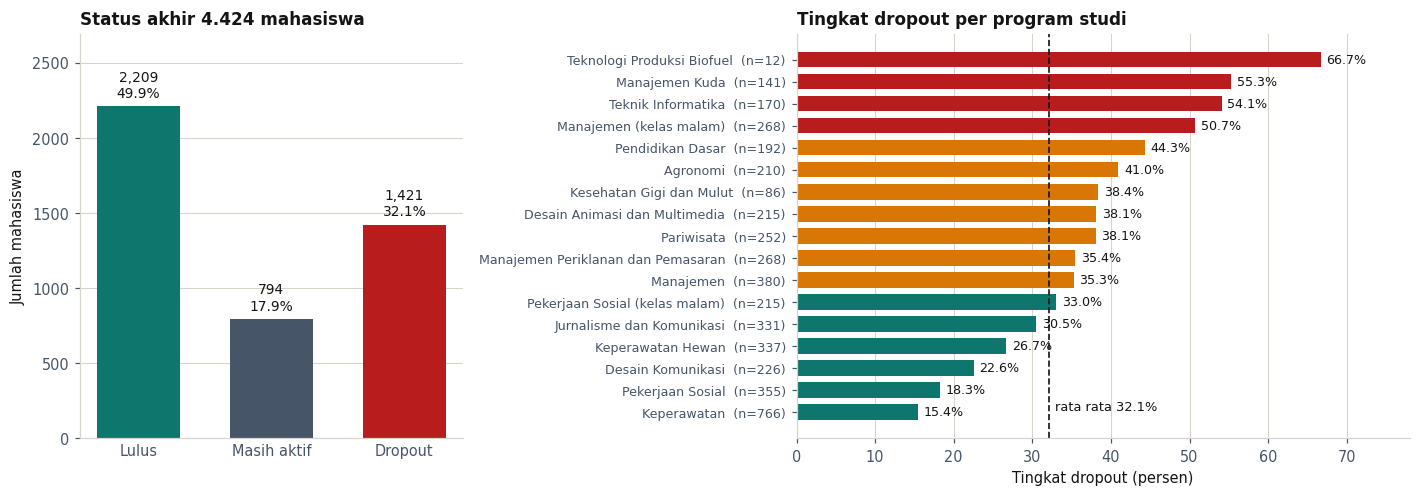

In [6]:
# --- Distribusi status dan sebaran per program studi ----------------------
d = fa.tambah_fitur(df)
d["dropout"] = (d.Status == "Dropout").astype(int)
d["prodi"] = d.Course.map(kk.PROGRAM_STUDI)

gambar, sumbu = plt.subplots(1, 2, figsize=(13, 4.6),
                             gridspec_kw={"width_ratios": [1, 1.6]})

urutan = ["Graduate", "Enrolled", "Dropout"]
nilai = [int((df.Status == s).sum()) for s in urutan]
warna = [TEAL, SLATE, MERAH]
batang = sumbu[0].bar(["Lulus", "Masih aktif", "Dropout"], nilai, color=warna, width=0.62)
for b, n in zip(batang, nilai):
    sumbu[0].text(b.get_x() + b.get_width() / 2, n + 40, f"{n:,}\n{n / len(df) * 100:.1f}%",
                  ha="center", va="bottom", fontsize=9, color=TINTA)
sumbu[0].set_title("Status akhir 4.424 mahasiswa")
sumbu[0].set_ylabel("Jumlah mahasiswa")
sumbu[0].set_ylim(0, max(nilai) * 1.22)
rapikan(sumbu[0], sembunyikan_x=True)

per_prodi = (d.groupby("prodi")
               .agg(jumlah=("dropout", "size"), rasio=("dropout", "mean"))
               .sort_values("rasio"))
posisi = np.arange(len(per_prodi))
warna_prodi = [MERAH if r >= 0.5 else (AMBER if r >= 0.35 else TEAL)
               for r in per_prodi.rasio]
sumbu[1].barh(posisi, per_prodi.rasio * 100, color=warna_prodi, height=0.7)
sumbu[1].set_yticks(posisi)
sumbu[1].set_yticklabels([f"{n}  (n={j})" for n, j in zip(per_prodi.index, per_prodi.jumlah)],
                         fontsize=8.3)
sumbu[1].axvline(d.dropout.mean() * 100, color=TINTA, linewidth=1.1, linestyle="--")
sumbu[1].text(d.dropout.mean() * 100 + 0.8, 0.1, f"rata rata {d.dropout.mean() * 100:.1f}%",
              fontsize=8.5, color=TINTA)
for p, r in zip(posisi, per_prodi.rasio):
    sumbu[1].text(r * 100 + 0.7, p, f"{r * 100:.1f}%", va="center", fontsize=8.3, color=TINTA)
sumbu[1].set_title("Tingkat dropout per program studi")
sumbu[1].set_xlabel("Tingkat dropout (persen)")
sumbu[1].set_xlim(0, 78)
sumbu[1].yaxis.grid(False)
sumbu[1].xaxis.grid(True)
for sisi in ("top", "right"):
    sumbu[1].spines[sisi].set_visible(False)

simpan(gambar, "01_status_dan_prodi")

**Insight 1.** Dari 4.424 mahasiswa, 1.421 orang atau 32,1 persen berakhir dropout,
2.209 orang atau 49,9 persen lulus, dan 794 orang atau 17,9 persen masih berstatus
aktif. Sepertiga angkatan yang tidak selesai adalah angka yang besar untuk sebuah
perguruan tinggi.

Angka rata rata itu menyembunyikan perbedaan yang tajam antar program studi. Rentangnya
membentang dari 15,4 persen di Keperawatan sampai 55,3 persen di Manajemen Kuda, dan
Teknik Informatika berada di 54,1 persen. Artinya masalah dropout bukan masalah
institusi secara merata, melainkan terkonsentrasi pada segelintir program studi.
Kelompok 794 mahasiswa aktif adalah kelompok yang hasil akhirnya belum ditentukan,
sehingga merekalah sasaran sesungguhnya dari sistem peringatan dini ini.

## 4. Exploratory Data Analysis

Pertanyaan yang dibawa ke tahap ini bukan sekadar variabel apa yang berkaitan dengan
dropout, melainkan variabel mana yang sudah dapat dibaca institusi sejak mahasiswa
diterima, dan variabel mana yang baru muncul setelah satu tahun berjalan. Karena itu
penelusuran dibagi mengikuti dua horizon proyek.

### 4.1. Sinyal yang sudah tersedia di gerbang masuk

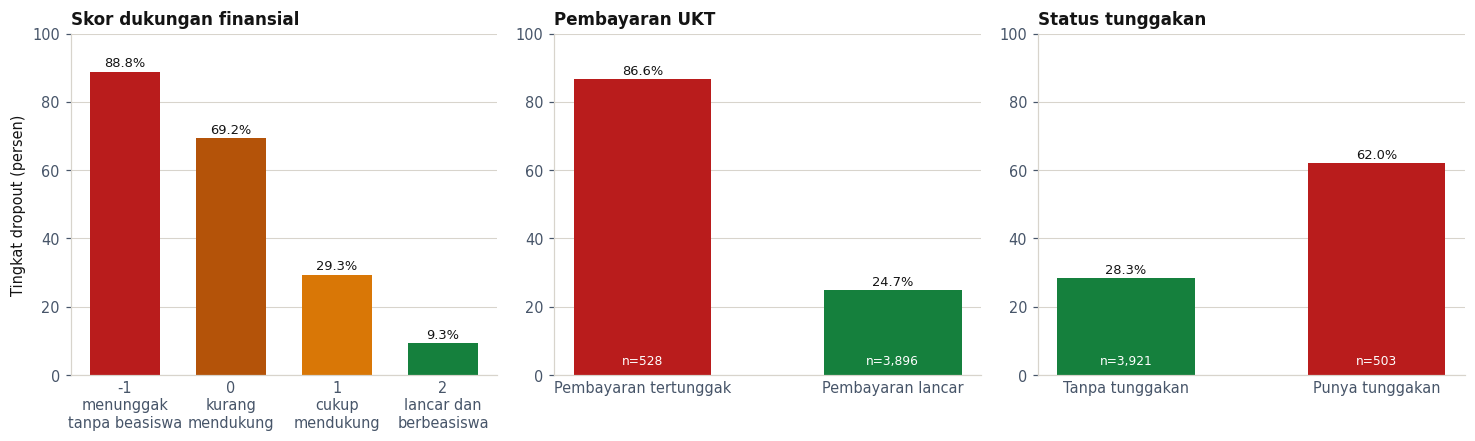

In [7]:
# --- Sinyal finansial ------------------------------------------------------
gambar, sumbu = plt.subplots(1, 3, figsize=(13.5, 4.1))


def rasio_per(kolom, urut_label=None):
    tabel = (d.groupby(kolom)
               .agg(jumlah=("dropout", "size"), rasio=("dropout", "mean")))
    if urut_label is not None:
        tabel = tabel.reindex(urut_label)
    return tabel


tabel = rasio_per("dukungan_finansial")
label = {-1: "-1\nmenunggak\ntanpa beasiswa", 0: "0\nkurang\nmendukung",
         1: "1\ncukup\nmendukung", 2: "2\nlancar dan\nberbeasiswa"}
warna_gradasi = [MERAH, EMAS, AMBER, HIJAU]
b = sumbu[0].bar([label[i] for i in tabel.index], tabel.rasio * 100,
                 color=warna_gradasi, width=0.66)
beri_label(sumbu[0], b, "%")
sumbu[0].set_title("Skor dukungan finansial")
sumbu[0].set_ylabel("Tingkat dropout (persen)")
sumbu[0].set_ylim(0, 100)
rapikan(sumbu[0], sembunyikan_x=True)

pasangan = [("Tuition_fees_up_to_date", "Pembayaran UKT"),
            ("Debtor", "Status tunggakan")]
for indeks, (kolom, judul) in enumerate(pasangan, start=1):
    tabel = rasio_per(kolom)
    nama_label = [kk.LABEL_BINER[kolom][i] for i in tabel.index]
    warna_pasangan = [HIJAU, MERAH] if kolom == "Debtor" else [MERAH, HIJAU]
    b = sumbu[indeks].bar(nama_label, tabel.rasio * 100, color=warna_pasangan, width=0.55)
    beri_label(sumbu[indeks], b, "%")
    for batang, jumlah in zip(b, tabel.jumlah):
        sumbu[indeks].text(batang.get_x() + batang.get_width() / 2, 3,
                           f"n={jumlah:,}", ha="center", fontsize=8, color="white")
    sumbu[indeks].set_title(judul)
    sumbu[indeks].set_ylim(0, 100)
    rapikan(sumbu[indeks], sembunyikan_x=True)

simpan(gambar, "02_sinyal_finansial")

**Insight 2.** Kondisi keuangan adalah sinyal paling tajam yang sudah dapat dibaca
institusi sejak hari pertama, dan ia bekerja seperti tangga yang rapi. Skor dukungan
finansial, yaitu gabungan status beasiswa, kelancaran pembayaran, dan status tunggakan,
memisahkan populasi dengan sangat jelas: 88,8 persen dropout pada kelompok skor -1 dan
hanya 9,3 persen pada kelompok skor 2. Perbedaan hampir sepuluh kali lipat ini muncul
dari tiga kolom yang sudah tercatat di sistem keuangan, tanpa perlu satu pun nilai ujian.

Dilihat satu per satu, mahasiswa dengan pembayaran uang kuliah tertunggak berakhir
dropout pada 86,6 persen kasus, dibanding 24,7 persen pada mahasiswa yang pembayarannya
lancar. Mahasiswa yang tercatat punya tunggakan berakhir dropout pada 62,0 persen kasus,
lebih dari dua kali lipat kelompok tanpa tunggakan.

Perlu kehati hatian dalam membaca arah sebab akibat di sini. Berhenti membayar bisa
menjadi penyebab mahasiswa keluar, tetapi bisa juga menjadi gejala dari keputusan
berhenti yang sudah diambil diam diam. Untuk keperluan peringatan dini, keduanya sama
sama berguna. Yang keliru adalah menyimpulkan bahwa memutihkan seluruh tunggakan
otomatis menurunkan dropout sebesar selisih di atas.

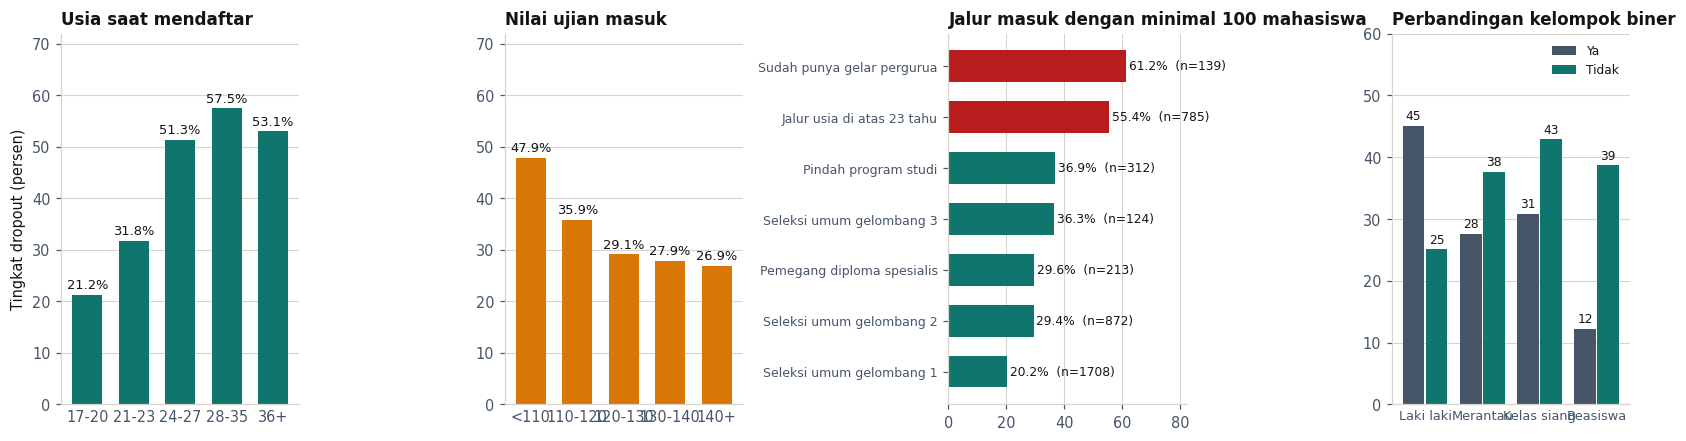

In [8]:
# --- Sinyal demografis dan riwayat pendaftaran ----------------------------
gambar, sumbu = plt.subplots(1, 4, figsize=(15, 4.1))

kelompok_usia = pd.cut(d.Age_at_enrollment, [16, 20, 23, 27, 35, 71],
                       labels=["17-20", "21-23", "24-27", "28-35", "36+"])
tabel = d.groupby(kelompok_usia, observed=True).agg(jumlah=("dropout", "size"),
                                                    rasio=("dropout", "mean"))
b = sumbu[0].bar(tabel.index.astype(str), tabel.rasio * 100, color=TEAL, width=0.65)
beri_label(sumbu[0], b, "%")
sumbu[0].set_title("Usia saat mendaftar")
sumbu[0].set_ylabel("Tingkat dropout (persen)")
sumbu[0].set_ylim(0, 72)
rapikan(sumbu[0], sembunyikan_x=True)

kelompok_nilai = pd.cut(d.Admission_grade, [94, 110, 120, 130, 140, 191],
                        labels=["<110", "110-120", "120-130", "130-140", "140+"])
tabel = d.groupby(kelompok_nilai, observed=True).agg(rasio=("dropout", "mean"))
b = sumbu[1].bar(tabel.index.astype(str), tabel.rasio * 100, color=AMBER, width=0.65)
beri_label(sumbu[1], b, "%")
sumbu[1].set_title("Nilai ujian masuk")
sumbu[1].set_ylim(0, 72)
rapikan(sumbu[1], sembunyikan_x=True)

jalur = (d.groupby("Application_mode")
           .agg(jumlah=("dropout", "size"), rasio=("dropout", "mean")))
jalur = jalur[jalur.jumlah >= 100].sort_values("rasio")
nama_jalur = [kk.JALUR_MASUK[i][:26] for i in jalur.index]
sumbu[2].barh(nama_jalur, jalur.rasio * 100,
              color=[MERAH if r > 0.5 else TEAL for r in jalur.rasio], height=0.62)
for indeks, (r, j) in enumerate(zip(jalur.rasio, jalur.jumlah)):
    sumbu[2].text(r * 100 + 1, indeks, f"{r * 100:.1f}%  (n={j})", va="center",
                  fontsize=8, color=TINTA)
sumbu[2].set_title("Jalur masuk dengan minimal 100 mahasiswa")
sumbu[2].set_xlim(0, 82)
sumbu[2].tick_params(axis="y", labelsize=8.2)
sumbu[2].yaxis.grid(False)
for sisi in ("top", "right"):
    sumbu[2].spines[sisi].set_visible(False)

biner = ["Gender", "Displaced", "Daytime_evening_attendance", "Scholarship_holder"]
posisi = np.arange(len(biner))
nilai_satu = [d[d[k] == 1].dropout.mean() * 100 for k in biner]
nilai_nol = [d[d[k] == 0].dropout.mean() * 100 for k in biner]
sumbu[3].bar(posisi - 0.2, nilai_satu, width=0.38, color=SLATE, label="Ya")
sumbu[3].bar(posisi + 0.2, nilai_nol, width=0.38, color=TEAL, label="Tidak")
sumbu[3].set_xticks(posisi)
sumbu[3].set_xticklabels(["Laki laki", "Merantau", "Kelas siang", "Beasiswa"], fontsize=8.4)
for x, (satu, nol) in enumerate(zip(nilai_satu, nilai_nol)):
    sumbu[3].text(x - 0.2, satu + 1, f"{satu:.0f}", ha="center", fontsize=8, color=TINTA)
    sumbu[3].text(x + 0.2, nol + 1, f"{nol:.0f}", ha="center", fontsize=8, color=TINTA)
sumbu[3].set_title("Perbandingan kelompok biner")
sumbu[3].set_ylim(0, 60)
sumbu[3].legend(fontsize=8, loc="upper right")
rapikan(sumbu[3], sembunyikan_x=True)

simpan(gambar, "03_sinyal_gerbang")

**Insight 3.** Di luar keuangan, gerbang masuk menyimpan tiga sinyal yang cukup kuat.

*Usia.* Tingkat dropout naik hampir tiga kali lipat dari 21,2 persen pada kelompok
17 sampai 20 tahun menjadi 57,5 persen pada kelompok 28 sampai 35 tahun. Mahasiswa yang
mendaftar pada usia lebih tua umumnya sudah bekerja atau berkeluarga, sehingga kuliah
harus bersaing dengan tanggung jawab lain.

*Jalur masuk.* Jalur usia di atas 23 tahun berakhir dropout pada 55,4 persen kasus
dengan 785 mahasiswa, sementara seleksi umum gelombang pertama hanya 20,2 persen dengan
1.708 mahasiswa. Selisih 35 poin persen antar jalur menunjukkan bahwa risiko sudah
melekat pada cara mahasiswa masuk, jauh sebelum ia mengikuti satu pun kuliah.

*Nilai ujian masuk.* Hubungannya searah tetapi jauh lebih landai, dari 47,9 persen pada
kelompok bernilai di bawah 110 menjadi 26,9 persen pada kelompok bernilai 140 ke atas.
Nilai masuk bukan penentu utama, hanya penyerta.

Dua catatan penting. Pertama, mahasiswa laki laki dropout pada 45,1 persen kasus
dibanding 25,1 persen pada mahasiswa perempuan, sebuah selisih besar yang perlu ditangani
sebagai perbedaan kebutuhan bimbingan, bukan sebagai alasan memperlakukan pendaftar
secara berbeda. Kedua, penerima beasiswa hanya dropout pada 12,2 persen kasus dibanding
38,7 persen pada bukan penerima. Angka ini menggoda untuk dibaca sebagai bukti bahwa
beasiswa mencegah dropout, padahal beasiswa juga diberikan kepada mahasiswa yang sejak
awal berprestasi. Yang bisa dipastikan hanyalah bahwa status beasiswa adalah penanda
kelompok berisiko rendah.

### 4.2. Sinyal yang baru muncul di akhir tahun pertama

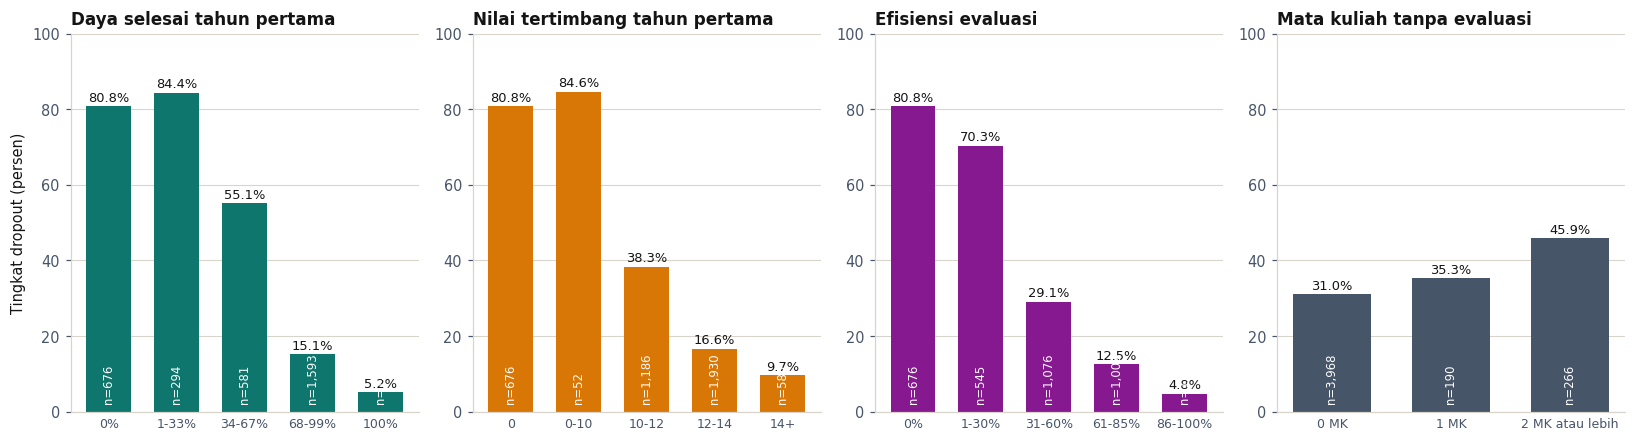

In [9]:
# --- Sinyal akademik tahun pertama ----------------------------------------
gambar, sumbu = plt.subplots(1, 4, figsize=(15, 4.1))

potong = [
    ("daya_selesai_th1", [-0.01, 0.001, 0.34, 0.67, 0.99, 1.001],
     ["0%", "1-33%", "34-67%", "68-99%", "100%"], "Daya selesai tahun pertama", TEAL),
    ("nilai_tertimbang", [-0.01, 0.001, 10, 12, 14, 19],
     ["0", "0-10", "10-12", "12-14", "14+"], "Nilai tertimbang tahun pertama", AMBER),
    ("efisiensi_ujian", [-0.01, 0.001, 0.3, 0.6, 0.85, 1.001],
     ["0%", "1-30%", "31-60%", "61-85%", "86-100%"], "Efisiensi evaluasi", PLUM),
    ("mk_tanpa_evaluasi", [-0.01, 0.001, 1.001, 30],
     ["0 MK", "1 MK", "2 MK atau lebih"], "Mata kuliah tanpa evaluasi", SLATE),
]

for indeks, (kolom, batas, label, judul, warna) in enumerate(potong):
    kelompok = pd.cut(d[kolom], batas, labels=label, include_lowest=True)
    tabel = d.groupby(kelompok, observed=True).agg(jumlah=("dropout", "size"),
                                                   rasio=("dropout", "mean"))
    b = sumbu[indeks].bar(tabel.index.astype(str), tabel.rasio * 100, color=warna, width=0.66)
    beri_label(sumbu[indeks], b, "%")
    for batang, jumlah in zip(b, tabel.jumlah):
        sumbu[indeks].text(batang.get_x() + batang.get_width() / 2, 3, f"n={jumlah:,}",
                           ha="center", fontsize=7.6, color="white", rotation=90)
    sumbu[indeks].set_title(judul)
    sumbu[indeks].set_ylim(0, 100)
    sumbu[indeks].tick_params(axis="x", labelsize=8.2)
    rapikan(sumbu[indeks], sembunyikan_x=True)

sumbu[0].set_ylabel("Tingkat dropout (persen)")
simpan(gambar, "04_sinyal_tahun_pertama")

**Insight 4.** Begitu catatan tahun pertama masuk, kekuatan pemisahnya jauh melampaui
seluruh sinyal gerbang.

*Daya selesai*, yaitu rasio mata kuliah lulus terhadap yang diambil, memisahkan populasi
paling tajam. Mahasiswa yang tidak meluluskan satu pun mata kuliah berakhir dropout pada
80,8 persen kasus, sedangkan yang meluluskan seluruh mata kuliahnya hanya 5,2 persen.
Rentang 75 poin persen ini tidak tertandingi variabel mana pun di tahap gerbang.

*Nilai tertimbang* bergerak searah, dari 84,6 persen pada kelompok bernilai di bawah 10
menjadi 9,7 persen pada kelompok bernilai 14 ke atas.

*Efisiensi evaluasi*, yaitu berapa banyak ujian yang benar benar berbuah kelulusan,
menangkap hal yang berbeda dari sekadar nilai: mahasiswa yang rajin ikut ujian tetapi
jarang lulus sedang berjuang dan gagal, bukan sedang absen.

*Mata kuliah tanpa evaluasi* adalah pengganti terdekat untuk data ketidakhadiran yang
tidak dimiliki dataset ini. Mahasiswa dengan dua mata kuliah atau lebih tanpa evaluasi
dropout pada 45,9 persen kasus, dibanding 31,0 persen pada mahasiswa tanpa kasus seperti
itu. Sinyalnya lebih lemah daripada daya selesai, tetapi ia muncul lebih awal dalam satu
semester karena tidak perlu menunggu nilai akhir keluar.

In [10]:
# --- Peringkat kekuatan sinyal lewat uji statistik ------------------------
# Kolom numerik diuji memakai Mann Whitney U karena sebagian besar sebarannya
# tidak normal, sedangkan kolom kategori diuji memakai chi square. Ukuran efek
# dilaporkan sebagai selisih rasio dropout antar kelompok teratas dan terbawah
# supaya besarnya dampak dapat dibandingkan, bukan hanya kebermaknaannya.
hasil_uji = []
kandidat_numerik = [k for k in fa.KOLOM_MENTAH + fa.TURUNAN_GERBANG + fa.TURUNAN_AKADEMIK
                    if k not in fa.KOLOM_KATEGORI and d[k].nunique() > 2]
for kolom in kandidat_numerik:
    kelompok_dropout = d.loc[d.dropout == 1, kolom]
    kelompok_lain = d.loc[d.dropout == 0, kolom]
    statistik_u, nilai_p = stats.mannwhitneyu(kelompok_dropout, kelompok_lain)
    # Common language effect size: peluang satu mahasiswa dropout bernilai lebih
    # tinggi daripada satu mahasiswa bukan dropout yang dipilih acak.
    efek = statistik_u / (len(kelompok_dropout) * len(kelompok_lain))
    hasil_uji.append((kolom, "Mann Whitney", nilai_p, abs(efek - 0.5) * 2))

for kolom in fa.KOLOM_KATEGORI + [k for k in fa.KOLOM_BINER if k in d.columns]:
    silang = pd.crosstab(d[kolom], d.dropout)
    khi, nilai_p, _, _ = stats.chi2_contingency(silang)
    cramer = np.sqrt(khi / (silang.to_numpy().sum() * (min(silang.shape) - 1)))
    hasil_uji.append((kolom, "Chi square", nilai_p, cramer))

peringkat = (pd.DataFrame(hasil_uji, columns=["Kolom", "Uji", "p", "Kekuatan"])
               .sort_values("Kekuatan", ascending=False)
               .reset_index(drop=True))
peringkat["Nama"] = peringkat.Kolom.map(kk.nama)
peringkat["Horizon"] = np.where(
    peringkat.Kolom.isin(fa.KOLOM_AKADEMIK + fa.TURUNAN_AKADEMIK),
    "Tahun pertama", "Gerbang")
peringkat["Bermakna"] = np.where(peringkat.p < 0.05, "ya", "tidak")
print("Lima belas sinyal terkuat")
print(peringkat.head(15)[["Nama", "Horizon", "Uji", "Kekuatan", "Bermakna"]]
      .round(3).to_string(index=False))
print()
print("Sinyal yang tidak bermakna secara statistik pada taraf 5 persen")
print(peringkat[peringkat.p >= 0.05][["Nama", "Uji", "Kekuatan"]].round(3).to_string(index=False))

Lima belas sinyal terkuat
                      Nama       Horizon          Uji  Kekuatan Bermakna
   Daya selesai semester 2 Tahun pertama Mann Whitney     0.748       ya
      Daya selesai tahun 1 Tahun pertama Mann Whitney     0.748       ya
        Efisiensi evaluasi Tahun pertama Mann Whitney     0.716       ya
       MK lulus semester 2 Tahun pertama Mann Whitney     0.710       ya
    Total MK lulus tahun 1 Tahun pertama Mann Whitney     0.694       ya
   Daya selesai semester 1 Tahun pertama Mann Whitney     0.680       ya
       MK lulus semester 1 Tahun pertama Mann Whitney     0.637       ya
Nilai rata rata semester 2 Tahun pertama Mann Whitney     0.628       ya
  Nilai tertimbang tahun 1 Tahun pertama Mann Whitney     0.568       ya
Nilai rata rata semester 1 Tahun pertama Mann Whitney     0.546       ya
   Skor dukungan finansial       Gerbang Mann Whitney     0.447       ya
     Status pembayaran UKT       Gerbang   Chi square     0.428       ya
       Usia saat mendafta

**Insight 5.** Peringkat uji statistik menegaskan pola yang terlihat pada grafik dan
sekaligus menjawab permasalahan bisnis pertama, yaitu faktor apa yang benar benar
menentukan.

Sepuluh besar sinyal terkuat hampir seluruhnya berasal dari horizon tahun pertama, dengan
daya selesai, jumlah mata kuliah lulus, dan nilai tertimbang di puncak daftar. Sinyal
gerbang terkuat adalah kelompok finansial dan usia, yang tetap masuk peringkat atas
meskipun kalah dari catatan akademik.

Yang sama pentingnya adalah daftar variabel yang tidak bermakna secara statistik. Tiga
kolom makroekonomi, kewarganegaraan, dan kebutuhan khusus tidak menunjukkan hubungan yang
dapat diandalkan dengan dropout pada data ini. Kolom kondisi makroekonomi bahkan secara
konsep tidak dapat dipakai untuk membedakan mahasiswa, karena nilainya sama untuk semua
mahasiswa pada tahun yang sama. Kolom kolom ini tetap disertakan sebagai masukan model,
tetapi tidak boleh dijadikan dasar penyusunan kebijakan.

Latar belakang keluarga, yang sering diasumsikan sebagai penentu, ternyata hanya
membedakan secara tipis: tingkat dropout pada kelompok pendidikan ibu jenjang perguruan
tinggi 30,2 persen, hampir sama dengan jenjang pendidikan dasar 31,5 persen. Satu satunya
kelompok yang menonjol adalah kategori tidak diketahui pada 73,5 persen, dan itu lebih
tepat dibaca sebagai penanda berkas pendaftaran yang tidak lengkap daripada sebagai
sifat keluarga mahasiswa.

### Ringkasan temuan EDA

1. Sepertiga angkatan berakhir dropout, dengan konsentrasi pada segelintir program studi.
2. Sejak di gerbang masuk, institusi sudah memegang tiga sinyal yang berguna: kondisi
   keuangan, usia, dan jalur masuk. Ketiganya cukup untuk menyusun peringkat kasar,
   tetapi tidak cukup untuk menuduh satu nama tertentu.
3. Setelah tahun pertama berjalan, daya selesai dan nilai tertimbang mengambil alih
   sebagai sinyal utama dengan daya pisah yang jauh lebih besar.
4. Beberapa variabel yang sering diasumsikan penting, yaitu latar belakang keluarga dan
   kondisi makroekonomi, ternyata tidak memberi informasi tambahan yang berarti.

Konsekuensinya untuk pemodelan: dua horizon memang perlu dipisah, karena keduanya
bekerja dengan bahan yang sangat berbeda kekuatannya, dan karenanya pantas dinilai
dengan harapan yang berbeda pula.

## 5. Data Preparation

### 5.1. Menentukan target yang boleh dipelajari

Kolom `Status` memiliki tiga nilai, tetapi hanya dua di antaranya yang merupakan hasil
akhir: `Dropout` dan `Graduate`. Status `Enrolled` berarti mahasiswa masih berkuliah dan
hasilnya belum diketahui. Memasukkan mereka ke data latih berarti mengajari model
menebak sesuatu yang jawabannya belum ada.

Karena itu 794 mahasiswa aktif dikeluarkan dari pelatihan dan disimpan terpisah. Mereka
justru menjadi sasaran akhir sistem ini: kelompok yang masih bisa diselamatkan, dan yang
akan diskor pada bagian 7.

In [11]:
# --- Memisahkan data latih dari mahasiswa yang masih aktif ---------------
data_model = df[df.Status.isin(["Dropout", "Graduate"])].copy()
data_aktif = df[df.Status == "Enrolled"].copy()

y = (data_model.Status == "Dropout").astype(int)
X = data_model.drop(columns=["Status"])

data_aktif.to_csv("dataset/mahasiswa_aktif.csv", index=False, sep=";")

print(f"Data berlabel untuk pemodelan : {len(X):,} mahasiswa")
print(f"  Dropout                     : {int(y.sum()):,} ({y.mean() * 100:.1f} persen)")
print(f"  Graduate                    : {int((1 - y).sum()):,} ({(1 - y).mean() * 100:.1f} persen)")
print(f"Mahasiswa aktif disimpan      : {len(data_aktif):,} baris ke dataset/mahasiswa_aktif.csv")
print()
print("Ketimpangan kelas 39 banding 61 tergolong ringan, sehingga tidak diperlukan")
print("oversampling. Ketidakseimbangan yang tersisa ditangani lewat pemilihan ambang")
print("keputusan pada tahap evaluasi, cara yang tidak menambah baris sintetis.")

Data berlabel untuk pemodelan : 3,630 mahasiswa
  Dropout                     : 1,421 (39.1 persen)
  Graduate                    : 2,209 (60.9 persen)
Mahasiswa aktif disimpan      : 794 baris ke dataset/mahasiswa_aktif.csv

Ketimpangan kelas 39 banding 61 tergolong ringan, sehingga tidak diperlukan
oversampling. Ketidakseimbangan yang tersisa ditangani lewat pemilihan ambang
keputusan pada tahap evaluasi, cara yang tidak menambah baris sintetis.


### 5.2. Menyusun dua himpunan fitur

Modul `fitur_akademik.py` menyusun sendiri daftar kolom untuk tiap horizon. Model gerbang
hanya menerima kolom yang sudah terisi saat pendaftaran, sedangkan model tahun pertama
menerima seluruh kolom. Fitur turunan ikut dibedakan: turunan akademik hanya dihitung
untuk horizon tahun pertama.

In [12]:
for horizon in ["gerbang", "tahun_pertama"]:
    kategori, biner, numerik = fa.bagi_kolom(horizon)
    mentah, turunan = fa.daftar_fitur(horizon)
    print(f"Horizon {horizon}")
    print(f"  kolom mentah   : {len(mentah)}")
    print(f"  fitur turunan  : {len(turunan)}  ->  {', '.join(turunan)}")
    print(f"  total masukan  : {len(mentah) + len(turunan)}"
          f"  (kategori {len(kategori)}, biner {len(biner)}, numerik {len(numerik)})")
    print()

contoh = fa.tambah_fitur(X.head(4))[fa.TURUNAN_GERBANG + fa.TURUNAN_AKADEMIK]
contoh.columns = [kk.nama(c) for c in contoh.columns]
print("Contoh hasil rekayasa fitur pada empat baris pertama")
contoh.round(3).T

Horizon gerbang
  kolom mentah   : 24
  fitur turunan  : 4  ->  selisih_adaptasi, jeda_masuk, dukungan_finansial, pilihan_pertama
  total masukan  : 28  (kategori 9, biner 9, numerik 10)

Horizon tahun_pertama
  kolom mentah   : 36
  fitur turunan  : 15  ->  selisih_adaptasi, jeda_masuk, dukungan_finansial, pilihan_pertama, beban_sks_th1, sks_lulus_th1, daya_selesai_th1, daya_selesai_sem1, daya_selesai_sem2, efisiensi_ujian, nilai_tertimbang, laju_nilai, mk_tanpa_evaluasi, sks_diakui, tanpa_beban_studi
  total masukan  : 51  (kategori 9, biner 10, numerik 32)

Contoh hasil rekayasa fitur pada empat baris pertama


,0,1,2,3
Selisih nilai masuk dan kualifikasi sebelumnya,5.3,-17.500,2.8,-2.400
Jeda tahun sebelum kuliah,2.0,1.000,1.0,2.000
Skor dukungan finansial,1.0,0.000,0.0,1.000
Diterima di pilihan pertama,0.0,1.000,0.0,0.000
Total MK diambil tahun 1,0.0,12.000,12.0,12.000
Total MK lulus tahun 1,0.0,12.000,0.0,11.000
Daya selesai tahun 1,0.0,1.000,0.0,0.917
Daya selesai semester 1,0.0,1.000,0.0,1.000
Daya selesai semester 2,0.0,1.000,0.0,0.833
Efisiensi evaluasi,0.0,1.000,0.0,0.611


### 5.3. Membagi data latih dan data uji

Pembagian dilakukan sekali di awal dengan proporsi 80 banding 20 dan stratifikasi pada
label, lalu dipakai untuk kedua horizon. Dengan begitu perbandingan antar horizon
dilakukan pada mahasiswa yang persis sama, sehingga selisih performa yang muncul benar
benar berasal dari perbedaan informasi, bukan dari perbedaan sampel.

Data uji tidak disentuh sama sekali selama pemilihan model maupun pemilihan ambang.
Seluruh keputusan diambil memakai validasi silang pada data latih.

In [13]:
X_latih, X_uji, y_latih, y_uji = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=ACAK)

lipat = StratifiedKFold(n_splits=5, shuffle=True, random_state=ACAK)

print(f"Data latih : {len(X_latih):,} mahasiswa, dropout {y_latih.mean() * 100:.2f} persen")
print(f"Data uji   : {len(X_uji):,} mahasiswa, dropout {y_uji.mean() * 100:.2f} persen")
print(f"Skema validasi silang: {lipat.get_n_splits()} lipatan berstrata")

Data latih : 2,904 mahasiswa, dropout 39.15 persen
Data uji   : 726 mahasiswa, dropout 39.12 persen
Skema validasi silang: 5 lipatan berstrata


### 5.4. Pipeline preprocessing

Seluruh transformasi dibungkus di dalam scikit-learn Pipeline, bukan dijalankan sebagai
langkah terpisah. Alasannya bukan kerapian semata: dengan Pipeline, penskalaan dan
penyandian kategori dipelajari ulang di dalam tiap lipatan validasi silang, sehingga
tidak ada informasi data validasi yang bocor ke data latih.

Dua bentuk preprocessing disiapkan karena dua keluarga model membutuhkan hal berbeda.

* **Untuk model berbasis pohon**, kolom kode kategori cukup disandikan menjadi bilangan
  urut memakai `OrdinalEncoder`, lalu diberitahukan kepada model sebagai kolom kategori.
  Pohon keputusan tidak mengasumsikan urutan pada angka tersebut, sehingga penyandian
  satu kolom per kategori tidak diperlukan dan dimensi data tetap kecil.
* **Untuk model linier**, kolom kategori harus dibuka menjadi kolom penanda memakai
  `OneHotEncoder`, dan kolom numerik harus diskalakan supaya besaran satuan yang berbeda
  tidak mendominasi bobot. Kategori yang sangat jarang digabungkan lewat parameter
  `min_frequency` agar model tidak menghafal kasus tunggal.

In [14]:
def pra_pohon(horizon):
    """Preprocessing untuk model berbasis pohon: kategori disandikan sebagai kode urut."""
    kategori, biner, numerik = fa.bagi_kolom(horizon)
    transformasi = ColumnTransformer(
        [("kategori", OrdinalEncoder(handle_unknown="use_encoded_value",
                                     unknown_value=np.nan), kategori),
         ("sisa", "passthrough", biner + numerik)],
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")
    return transformasi, kategori


def pra_linier(horizon):
    """Preprocessing untuk model linier: kategori dibuka, kolom numerik diskalakan."""
    kategori, biner, numerik = fa.bagi_kolom(horizon)
    return ColumnTransformer(
        [("kategori", OneHotEncoder(handle_unknown="ignore", min_frequency=20,
                                    sparse_output=False), kategori),
         ("biner", "passthrough", biner),
         ("numerik", StandardScaler(), numerik)],
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")


def bangun_pipa(horizon, jenis):
    """Merangkai rekayasa fitur, preprocessing, dan model menjadi satu objek utuh."""
    langkah_fitur = ("fitur", FunctionTransformer(fa.tambah_fitur))

    if jenis == "logistik":
        return Pipeline([
            langkah_fitur,
            ("pra", pra_linier(horizon)),
            ("model", LogisticRegression(max_iter=3000, C=0.5, class_weight="balanced",
                                         random_state=ACAK)),
        ])

    pra, kolom_kategori = pra_pohon(horizon)
    if jenis == "hutan_acak":
        mesin = RandomForestClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1,
                                       class_weight="balanced_subsample", random_state=ACAK)
    elif jenis == "extra_trees":
        mesin = ExtraTreesClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1,
                                     class_weight="balanced", random_state=ACAK)
    elif jenis == "hist_gradient":
        mesin = HistGradientBoostingClassifier(categorical_features=kolom_kategori,
                                               early_stopping=False, random_state=ACAK)
    else:
        raise ValueError(f"Jenis model tidak dikenal: {jenis}")

    return Pipeline([langkah_fitur, ("pra", pra), ("model", mesin)])


contoh_pipa = bangun_pipa("tahun_pertama", "extra_trees")
contoh_pipa

,steps,"[('fitur', ...), ('pra', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function tam...001F7B3852020>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


## 6. Modeling

### 6.1. Membandingkan empat keluarga model pada kedua horizon

Empat kandidat diuji untuk setiap horizon, dipilih karena cara kerjanya benar benar
berbeda satu sama lain, bukan karena namanya populer.

| Kandidat | Cara kerja | Alasan dicoba |
|---|---|---|
| Regresi Logistik | Menjumlahkan pengaruh tiap fitur secara linier | Tolok ukur yang jujur dan mudah dijelaskan ke pihak akademik |
| Random Forest | Rata rata banyak pohon yang dilatih pada contoh acak | Menangkap interaksi antar fitur tanpa perlu penyetelan berat |
| Extra Trees | Seperti Random Forest tetapi titik potong dipilih acak | Ragamnya lebih tinggi sehingga sering lebih tahan terhadap overfitting |
| Hist Gradient Boosting | Pohon dibangun bertahap, tiap pohon memperbaiki sisa kesalahan | Umumnya paling kuat pada data tabular berukuran sedang |

Ukuran pembanding utamanya adalah PR-AUC, bukan akurasi. Pada masalah dengan kelas
positif minoritas, akurasi dapat terlihat tinggi hanya dengan menebak semua mahasiswa
akan lulus. PR-AUC merangkum keseimbangan presisi dan recall khusus untuk kelas yang
kita pedulikan, yaitu mahasiswa yang berisiko berhenti.

Seluruh angka pada tabel berikut dihitung lewat validasi silang lima lipatan pada data
latih. Data uji belum disentuh sampai bagian 7.

In [15]:
KANDIDAT = ["logistik", "hutan_acak", "extra_trees", "hist_gradient"]
NAMA_KANDIDAT = {
    "logistik": "Regresi Logistik",
    "hutan_acak": "Random Forest",
    "extra_trees": "Extra Trees",
    "hist_gradient": "Hist Gradient Boosting",
}

hasil_banding = []
probabilitas_cv = {}

for horizon in ["gerbang", "tahun_pertama"]:
    for jenis in KANDIDAT:
        peluang = cross_val_predict(bangun_pipa(horizon, jenis), X_latih, y_latih,
                                    cv=lipat, method="predict_proba", n_jobs=-1)[:, 1]
        probabilitas_cv[(horizon, jenis)] = peluang
        hasil_banding.append({
            "Horizon": horizon,
            "Model": NAMA_KANDIDAT[jenis],
            "ROC-AUC": roc_auc_score(y_latih, peluang),
            "PR-AUC": average_precision_score(y_latih, peluang),
            "F1 pada 0,5": f1_score(y_latih, (peluang >= 0.5).astype(int)),
        })

banding = pd.DataFrame(hasil_banding)
print("Perbandingan kandidat model, validasi silang lima lipatan pada data latih")
print(banding.round(4).to_string(index=False))

TERBAIK = {}
for horizon in ["gerbang", "tahun_pertama"]:
    bagian = banding[banding.Horizon == horizon].sort_values("PR-AUC", ascending=False)
    nama_menang = bagian.iloc[0].Model
    TERBAIK[horizon] = next(k for k, v in NAMA_KANDIDAT.items() if v == nama_menang)
    print(f"\nKandidat terpilih horizon {horizon}: {nama_menang} "
          f"(PR-AUC {bagian.iloc[0]['PR-AUC']:.4f})")

Perbandingan kandidat model, validasi silang lima lipatan pada data latih
      Horizon                  Model  ROC-AUC  PR-AUC  F1 pada 0,5
      gerbang       Regresi Logistik   0.8467  0.8142       0.7091
      gerbang          Random Forest   0.8288  0.7939       0.6714
      gerbang            Extra Trees   0.8213  0.7869       0.6814
      gerbang Hist Gradient Boosting   0.8297  0.8017       0.6856
tahun_pertama       Regresi Logistik   0.9539  0.9503       0.8793
tahun_pertama          Random Forest   0.9553  0.9533       0.8804
tahun_pertama            Extra Trees   0.9559  0.9542       0.8821
tahun_pertama Hist Gradient Boosting   0.9528  0.9509       0.8850

Kandidat terpilih horizon gerbang: Regresi Logistik (PR-AUC 0.8142)

Kandidat terpilih horizon tahun_pertama: Extra Trees (PR-AUC 0.9542)


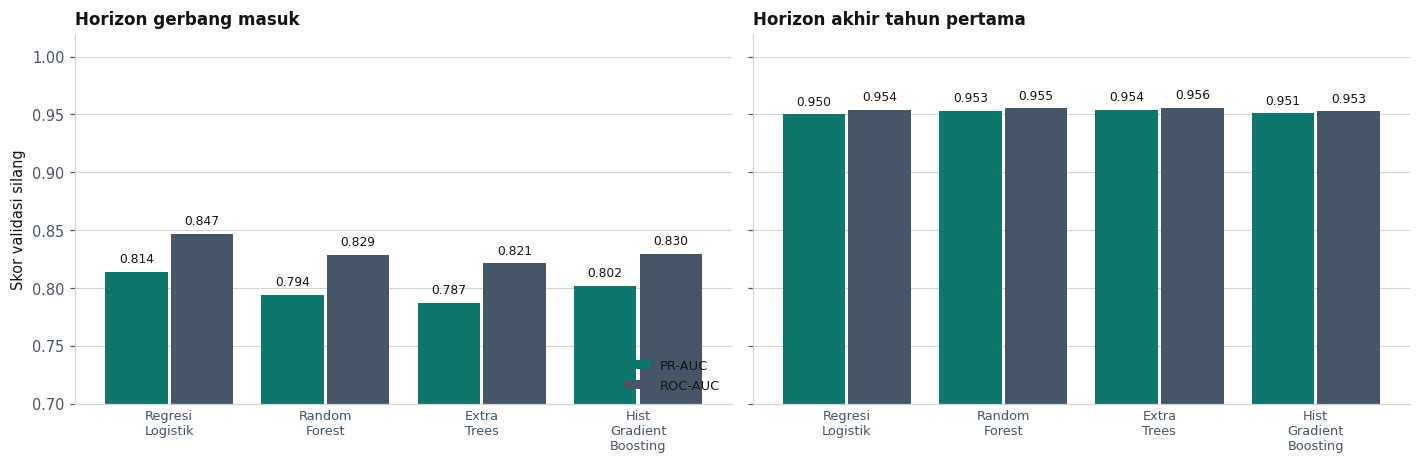

In [16]:
# --- Grafik perbandingan kandidat ----------------------------------------
gambar, sumbu = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)

for indeks, horizon in enumerate(["gerbang", "tahun_pertama"]):
    bagian = banding[banding.Horizon == horizon]
    posisi = np.arange(len(bagian))
    sumbu[indeks].bar(posisi - 0.21, bagian["PR-AUC"], width=0.4, color=TEAL, label="PR-AUC")
    sumbu[indeks].bar(posisi + 0.21, bagian["ROC-AUC"], width=0.4, color=SLATE, label="ROC-AUC")
    for x, (pr, roc) in enumerate(zip(bagian["PR-AUC"], bagian["ROC-AUC"])):
        sumbu[indeks].text(x - 0.21, pr + 0.008, f"{pr:.3f}", ha="center", fontsize=8)
        sumbu[indeks].text(x + 0.21, roc + 0.008, f"{roc:.3f}", ha="center", fontsize=8)
    sumbu[indeks].set_xticks(posisi)
    sumbu[indeks].set_xticklabels([n.replace(" ", "\n") for n in bagian.Model], fontsize=8.4)
    judul = "Horizon gerbang masuk" if horizon == "gerbang" else "Horizon akhir tahun pertama"
    sumbu[indeks].set_title(judul)
    sumbu[indeks].set_ylim(0.7, 1.02)
    rapikan(sumbu[indeks], sembunyikan_x=True)

sumbu[0].set_ylabel("Skor validasi silang")
sumbu[0].legend(fontsize=8.5, loc="lower right")
simpan(gambar, "05_perbandingan_kandidat")

**Insight 6.** Dua horizon menghasilkan pemenang yang berbeda, dan perbedaan itu masuk
akal secara teknis.

Pada horizon gerbang masuk, Regresi Logistik justru mengungguli ketiga model pohon
dengan PR-AUC 0,814 berbanding 0,787 sampai 0,802. Ini bukan kebetulan. Sinyal yang
tersedia di gerbang, yaitu kondisi keuangan, usia, dan nilai masuk, bergerak searah dan
hampir tanpa lekukan. Model linier menangkap pola semacam itu dengan efisien, sementara
model pohon menghabiskan kapasitasnya mencari interaksi yang sebenarnya tidak ada dan
berakhir dengan sedikit overfitting.

Pada horizon akhir tahun pertama keadaannya berbalik. Keempat model melompat ke kisaran
PR-AUC 0,950 sampai 0,954, dan Extra Trees keluar sebagai yang tertinggi. Ketika catatan
akademik masuk, muncul pola berambang, misalnya risiko yang melonjak begitu daya selesai
turun di bawah kira kira setengah, dan pola seperti itu memang wilayah kerja model pohon.

Lompatan dari kisaran 0,81 ke kisaran 0,95 adalah temuan bisnis, bukan sekadar temuan
teknis. Ia mengukur berapa banyak kepastian yang didapat institusi dengan menunggu satu
tahun, dan sekaligus berapa banyak yang harus dikorbankan bila ingin bertindak lebih awal.

### 6.2. Penyetelan hiperparameter

Kandidat terpilih di tiap horizon disetel memakai pencarian grid dengan validasi silang
yang sama. Ruang pencarian sengaja dibuat kecil dan terarah pada parameter yang paling
menentukan bagi keluarga model bersangkutan, karena grid yang terlalu lebar hanya
memperbesar peluang menemukan kombinasi yang kebetulan bagus di data latih.

In [17]:
RUANG_PARAMETER = {
    "logistik": {
        # C mengatur kekuatan penalti: makin kecil makin sederhana modelnya.
        "model__C": [0.05, 0.1, 0.3, 1.0, 3.0],
        # Ambang frekuensi minimum sebelum sebuah kategori digabung ke kelompok lain.
        "pra__kategori__min_frequency": [10, 25, 50],
    },
    # Jumlah pohon dibatasi 300 dan daun terkecil tidak boleh di bawah dua.
    # Batas ini bukan soal ketelitian melainkan soal ukuran berkas: model harus
    # dimuat ulang oleh Streamlit Community Cloud setiap kali aplikasi dinyalakan.
    "hutan_acak": {
        "model__n_estimators": [300],
        "model__min_samples_leaf": [2, 5, 10],
        "model__max_features": ["sqrt", 0.3],
    },
    "extra_trees": {
        "model__n_estimators": [300],
        "model__min_samples_leaf": [2, 5, 10],
        "model__max_features": ["sqrt", 0.3],
    },
    "hist_gradient": {
        "model__learning_rate": [0.05, 0.1],
        "model__max_leaf_nodes": [15, 31],
        "model__min_samples_leaf": [10, 25],
        "model__l2_regularization": [0.0, 1.0],
        "model__max_iter": [300],
    },
}

PIPA_TERSETEL = {}
for horizon in ["gerbang", "tahun_pertama"]:
    jenis = TERBAIK[horizon]
    pencarian = GridSearchCV(bangun_pipa(horizon, jenis), RUANG_PARAMETER[jenis],
                             scoring="average_precision", cv=lipat, n_jobs=-1)
    pencarian.fit(X_latih, y_latih)
    PIPA_TERSETEL[horizon] = pencarian.best_estimator_
    dasar = banding[(banding.Horizon == horizon)
                    & (banding.Model == NAMA_KANDIDAT[jenis])]["PR-AUC"].iloc[0]
    print(f"Horizon {horizon}  |  {NAMA_KANDIDAT[jenis]}")
    print(f"  kombinasi diuji : {len(pencarian.cv_results_['params'])}")
    print(f"  parameter terbaik: {pencarian.best_params_}")
    print(f"  PR-AUC sebelum disetel : {dasar:.4f}")
    print(f"  PR-AUC setelah disetel : {pencarian.best_score_:.4f}")
    print()

Horizon gerbang  |  Regresi Logistik
  kombinasi diuji : 15
  parameter terbaik: {'model__C': 0.3, 'pra__kategori__min_frequency': 10}
  PR-AUC sebelum disetel : 0.8142
  PR-AUC setelah disetel : 0.8164



Horizon tahun_pertama  |  Extra Trees
  kombinasi diuji : 6
  parameter terbaik: {'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
  PR-AUC sebelum disetel : 0.9542
  PR-AUC setelah disetel : 0.9551



### 6.3. Mengkalibrasi probabilitas

Model klasifikasi mengeluarkan angka antara nol dan satu, tetapi angka itu belum tentu
berarti peluang. Model pohon cenderung menumpuk keluarannya di sekitar nilai tengah,
sedangkan model linier dengan pembobotan kelas justru menggesernya ke atas.

Untuk proyek ini keluaran model harus benar benar terbaca sebagai peluang, karena dua
alasan. Pertama, ambang keputusan akan dipilih lewat perhitungan biaya yang hanya masuk
akal jika angka 0,3 memang berarti tiga dari sepuluh mahasiswa serupa akan berhenti.
Kedua, staf akademik akan membaca angka itu langsung di layar prototipe.

Karena itu setiap pipeline dibungkus `CalibratedClassifierCV`. Dua metode pemetaan diuji
dan yang lebih baik dipilih berdasarkan bukti, bukan kebiasaan.

* **Isotonik** mempelajari fungsi tangga yang bebas bentuk. Ia sangat lentur, tetapi
  karena berupa tangga, ujung sebarannya dipetakan ke nilai persis nol dan persis satu.
* **Platt scaling** memetakan skor lewat kurva sigmoid berparameter dua. Bentuknya lebih
  kaku, tetapi keluarannya tidak pernah menyentuh nol maupun satu.

Pemilih utamanya adalah skor Brier pada probabilitas luar lipatan, yaitu rata rata
kuadrat selisih antara peluang yang dijanjikan dan kenyataan. Pertimbangan kedua adalah
jumlah prediksi yang tersaturasi di nilai ekstrem, karena angka 1,00 di layar prototipe
akan terbaca staf sebagai kepastian mutlak, padahal tidak ada model yang berhak
menjanjikan itu tentang masa depan seorang mahasiswa.

Parameter `ensemble=False` dipakai agar berkas akhir hanya menyimpan satu model yang
dilatih pada seluruh data latih beserta satu fungsi kalibrasi, bukan lima salinan model
dari lima lipatan. Pilihan ini memperkecil berkas model sekitar lima kali lipat dengan
selisih performa yang dapat diabaikan, dan itu menentukan apakah prototipe dapat dimuat
dengan wajar di Streamlit Community Cloud.

In [18]:
# --- Membandingkan dua metode kalibrasi ----------------------------------
PELUANG_CV = {}      # probabilitas luar lipatan pada data latih, untuk memilih ambang
METODE_KALIBRASI = {}
perbandingan_kalibrasi = []

for horizon in ["gerbang", "tahun_pertama"]:
    simpanan = {}
    for metode in ["isotonic", "sigmoid"]:
        pembungkus = CalibratedClassifierCV(PIPA_TERSETEL[horizon], method=metode,
                                            cv=5, ensemble=False)
        peluang = cross_val_predict(pembungkus, X_latih, y_latih, cv=lipat,
                                    method="predict_proba", n_jobs=-1)[:, 1]
        simpanan[metode] = peluang
        perbandingan_kalibrasi.append({
            "Horizon": horizon,
            "Metode": "Isotonik" if metode == "isotonic" else "Platt scaling",
            "Brier": brier_score_loss(y_latih, peluang),
            "PR-AUC": average_precision_score(y_latih, peluang),
            "Prediksi tersaturasi": int(((peluang >= 0.999) | (peluang <= 0.001)).sum()),
        })
    terpilih = min(simpanan, key=lambda m: brier_score_loss(y_latih, simpanan[m]))
    METODE_KALIBRASI[horizon] = terpilih
    PELUANG_CV[horizon] = simpanan[terpilih]

print("Perbandingan metode kalibrasi, probabilitas luar lipatan pada data latih")
print(pd.DataFrame(perbandingan_kalibrasi).round(4).to_string(index=False))
print()
for horizon, metode in METODE_KALIBRASI.items():
    print(f"Metode terpilih horizon {horizon}: "
          f"{'Isotonik' if metode == 'isotonic' else 'Platt scaling'}")

Perbandingan metode kalibrasi, probabilitas luar lipatan pada data latih
      Horizon        Metode  Brier  PR-AUC  Prediksi tersaturasi
      gerbang      Isotonik 0.1501  0.8074                    72
      gerbang Platt scaling 0.1488  0.8153                     1
tahun_pertama      Isotonik 0.0676  0.9501                   899
tahun_pertama Platt scaling 0.0672  0.9542                     0

Metode terpilih horizon gerbang: Platt scaling
Metode terpilih horizon tahun_pertama: Platt scaling


**Insight 7.** Platt scaling menang di kedua horizon, dan menangnya bukan tipis dalam
hal yang penting. Skor Briernya sedikit lebih baik, 0,0672 berbanding 0,0676 pada horizon
tahun pertama, tetapi selisih yang menentukan ada di kolom terakhir: isotonik memaksa 899
dari 2.904 prediksi menjadi persis nol atau persis satu, sedangkan Platt scaling tidak
menghasilkan satu pun.

Angka 1,00 di layar berarti model menyatakan mahasiswa itu pasti berhenti, tanpa
kemungkinan lain. Untuk sebuah keputusan yang berujung pada percakapan antara dosen wali
dan mahasiswa, klaim sekuat itu tidak dapat dipertanggungjawabkan, apalagi ia lahir dari
keterbatasan bentuk fungsi tangga dan bukan dari keyakinan yang benar benar dimiliki
model. Karena itu kedua horizon memakai Platt scaling.

In [19]:
# --- Melatih model final dengan metode kalibrasi terpilih ----------------
# Probabilitas luar lipatan pada PELUANG_CV dipakai untuk memilih ambang, sedangkan
# probabilitas data uji hanya dipakai untuk melaporkan hasil akhir.
MODEL_FINAL = {}
PELUANG_UJI = {}

for horizon in ["gerbang", "tahun_pertama"]:
    terkalibrasi = CalibratedClassifierCV(PIPA_TERSETEL[horizon],
                                          method=METODE_KALIBRASI[horizon],
                                          cv=5, ensemble=False)
    terkalibrasi.fit(X_latih, y_latih)
    MODEL_FINAL[horizon] = terkalibrasi
    PELUANG_UJI[horizon] = terkalibrasi.predict_proba(X_uji)[:, 1]
    print(f"Horizon {horizon:14s} selesai dilatih dan dikalibrasi. "
          f"Brier data uji {brier_score_loss(y_uji, PELUANG_UJI[horizon]):.4f}, "
          f"rentang skor {PELUANG_UJI[horizon].min():.3f} sampai "
          f"{PELUANG_UJI[horizon].max():.3f}")

Horizon gerbang        selesai dilatih dan dikalibrasi. Brier data uji 0.1403, rentang skor 0.017 sampai 0.995


Horizon tahun_pertama  selesai dilatih dan dikalibrasi. Brier data uji 0.0680, rentang skor 0.028 sampai 0.980


## 7. Evaluation

### 7.1. Daya pisah pada data uji

Data uji berisi 726 mahasiswa yang belum pernah dilihat model sama sekali, tidak pada
saat pelatihan, tidak pada saat penyetelan parameter, dan tidak pada saat pemilihan
ambang. Dua kurva berikut mengukur daya pisah model tanpa bergantung pada ambang apa pun.

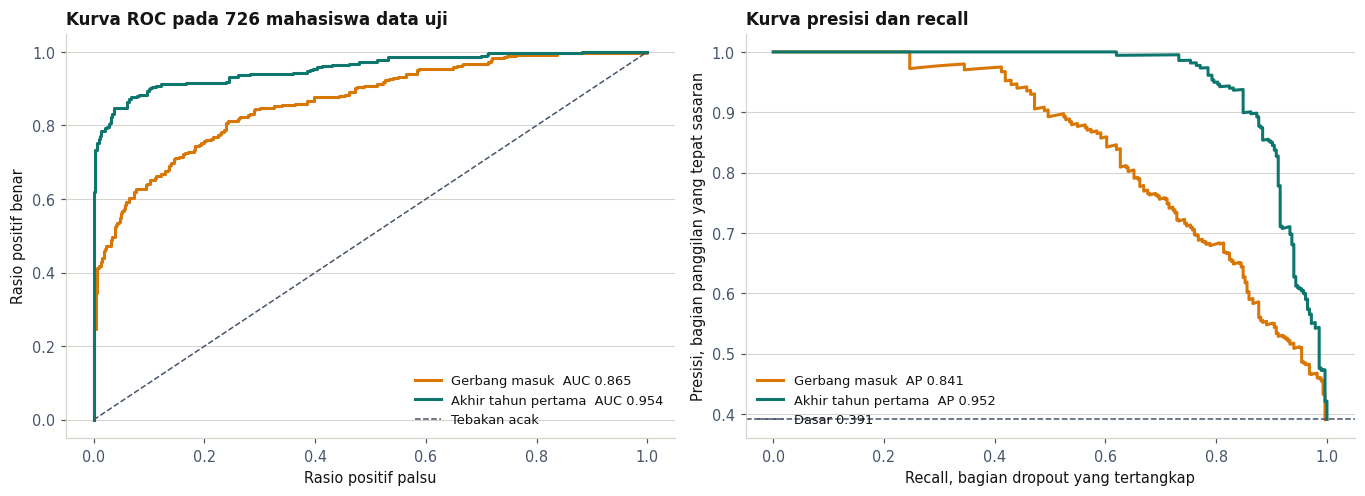

Gerbang masuk          pada recall 0.70 presisi tertinggi 0.757
Gerbang masuk          pada recall 0.80 presisi tertinggi 0.683
Gerbang masuk          pada recall 0.90 presisi tertinggi 0.551
Akhir tahun pertama    pada recall 0.70 presisi tertinggi 0.995
Akhir tahun pertama    pada recall 0.80 presisi tertinggi 0.950
Akhir tahun pertama    pada recall 0.90 presisi tertinggi 0.850


In [20]:
gambar, sumbu = plt.subplots(1, 2, figsize=(12.5, 4.6))
warna_horizon = {"gerbang": AMBER, "tahun_pertama": TEAL}
label_horizon = {"gerbang": "Gerbang masuk", "tahun_pertama": "Akhir tahun pertama"}

for horizon in ["gerbang", "tahun_pertama"]:
    peluang = PELUANG_UJI[horizon]
    fpr, tpr, _ = roc_curve(y_uji, peluang)
    sumbu[0].plot(fpr, tpr, color=warna_horizon[horizon], linewidth=2,
                  label=f"{label_horizon[horizon]}  AUC {roc_auc_score(y_uji, peluang):.3f}")
    presisi, recall, _ = precision_recall_curve(y_uji, peluang)
    sumbu[1].plot(recall, presisi, color=warna_horizon[horizon], linewidth=2,
                  label=f"{label_horizon[horizon]}  AP {average_precision_score(y_uji, peluang):.3f}")

sumbu[0].plot([0, 1], [0, 1], color=SLATE, linestyle="--", linewidth=1, label="Tebakan acak")
sumbu[0].set_title("Kurva ROC pada 726 mahasiswa data uji")
sumbu[0].set_xlabel("Rasio positif palsu")
sumbu[0].set_ylabel("Rasio positif benar")
sumbu[0].legend(fontsize=8.5, loc="lower right")

sumbu[1].axhline(y_uji.mean(), color=SLATE, linestyle="--", linewidth=1,
                 label=f"Dasar {y_uji.mean():.3f}")
sumbu[1].set_title("Kurva presisi dan recall")
sumbu[1].set_xlabel("Recall, bagian dropout yang tertangkap")
sumbu[1].set_ylabel("Presisi, bagian panggilan yang tepat sasaran")
sumbu[1].legend(fontsize=8.5, loc="lower left")

for s in sumbu:
    rapikan(s)
simpan(gambar, "06_roc_dan_presisi_recall")

# Presisi yang masih dapat dipertahankan pada beberapa tingkat penangkapan.
for horizon in ["gerbang", "tahun_pertama"]:
    presisi, recall, _ = precision_recall_curve(y_uji, PELUANG_UJI[horizon])
    for sasaran in [0.70, 0.80, 0.90]:
        indeks = np.where(recall >= sasaran)[0]
        print(f"{label_horizon[horizon]:22s} pada recall {sasaran:.2f} "
              f"presisi tertinggi {presisi[indeks[-1]]:.3f}")

**Insight 8.** Kedua model mengungguli tebakan acak dengan selisih yang lebar, tetapi
jaraknya satu sama lain tetap jelas. Model tahun pertama mencapai ROC-AUC 0,954 dan
PR-AUC 0,952, sedangkan model gerbang berada di ROC-AUC 0,865 dan PR-AUC 0,841 dengan
garis dasar 0,391.

Cara membaca yang paling berguna adalah lewat kurva presisi dan recall. Pada recall
0,80, artinya delapan dari sepuluh calon dropout tertangkap, model tahun pertama masih
mempertahankan presisi 0,950, sementara model gerbang turun ke 0,683. Artinya, pada
tingkat penangkapan yang sama, bimbingan yang dijadwalkan berdasarkan model gerbang akan
jauh lebih sering menghampiri mahasiswa yang sebenarnya baik baik saja: kira kira tiga
dari sepuluh panggilan, dibanding satu dari dua puluh pada model tahun pertama.

Ini bukan kegagalan model gerbang. Ia bekerja tanpa satu pun nilai kuliah, dan tetap
memberi peringkat yang jauh lebih baik daripada menebak. Yang perlu berbeda adalah cara
memakainya: model gerbang untuk menyaring kelompok, model tahun pertama untuk menunjuk
nama.

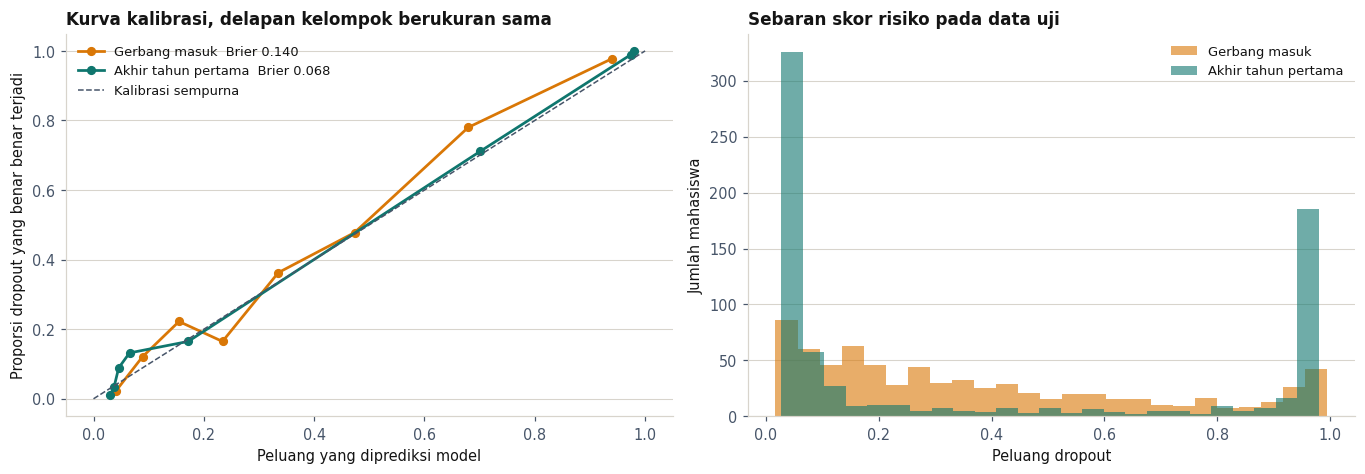

In [21]:
# --- Pemeriksaan kalibrasi ------------------------------------------------
gambar, sumbu = plt.subplots(1, 2, figsize=(12.5, 4.4))

for horizon in ["gerbang", "tahun_pertama"]:
    peluang = PELUANG_UJI[horizon]
    nyata, prediksi = calibration_curve(y_uji, peluang, n_bins=8, strategy="quantile")
    sumbu[0].plot(prediksi, nyata, "o-", color=warna_horizon[horizon], linewidth=1.8,
                  markersize=5,
                  label=f"{label_horizon[horizon]}  Brier {brier_score_loss(y_uji, peluang):.3f}")
    sumbu[1].hist(peluang, bins=25, alpha=0.6, color=warna_horizon[horizon],
                  label=label_horizon[horizon])

sumbu[0].plot([0, 1], [0, 1], color=SLATE, linestyle="--", linewidth=1,
              label="Kalibrasi sempurna")
sumbu[0].set_title("Kurva kalibrasi, delapan kelompok berukuran sama")
sumbu[0].set_xlabel("Peluang yang diprediksi model")
sumbu[0].set_ylabel("Proporsi dropout yang benar benar terjadi")
sumbu[0].legend(fontsize=8.5, loc="upper left")

sumbu[1].set_title("Sebaran skor risiko pada data uji")
sumbu[1].set_xlabel("Peluang dropout")
sumbu[1].set_ylabel("Jumlah mahasiswa")
sumbu[1].legend(fontsize=8.5)

for s in sumbu:
    rapikan(s)
simpan(gambar, "07_kalibrasi")

**Insight 9.** Titik titik kalibrasi kedua model menempel pada garis diagonal, dengan
skor Brier 0,068 untuk model tahun pertama dan 0,140 untuk model gerbang. Artinya angka
yang ditampilkan prototipe boleh dibaca apa adanya: kelompok mahasiswa yang diberi skor
sekitar 0,30 memang sekitar tiga dari sepuluh yang berakhir dropout.

Sifat ini penting karena tanpa kalibrasi, staf akademik tidak punya cara membandingkan
dua mahasiswa dengan skor 0,45 dan 0,75 selain mengatakan yang satu lebih tinggi. Dengan
kalibrasi, selisih itu punya arti dalam satuan peluang, dan perhitungan biaya pada bagian
berikutnya menjadi sah.

Bentuk sebaran skornya pun berbeda dan sesuai dugaan. Model tahun pertama menumpuk
mahasiswa di dua ujung, tanda ia berani mengambil sikap. Model gerbang menumpuk di
tengah, tanda ia mengakui ketidaktahuannya, yang justru merupakan perilaku yang benar
ketika informasinya memang belum lengkap.

### 7.2. Memilih ambang keputusan lewat perhitungan biaya

Ambang bawaan 0,5 mengandaikan bahwa dua jenis kesalahan sama mahalnya. Pada kasus ini
anggapan tersebut jelas keliru.

* **Melewatkan calon dropout** berarti institusi kehilangan sisa uang kuliah bertahun
  tahun, kehilangan satu lulusan yang seharusnya menambah reputasi, dan menanggung biaya
  akuisisi mahasiswa baru sebagai pengganti.
* **Memanggil mahasiswa yang sebenarnya baik baik saja** berarti institusi memakai satu
  slot jam bimbingan untuk orang yang mungkin tidak membutuhkannya. Biayanya nyata,
  tetapi jauh lebih kecil.

Perbandingan biaya dasar proyek ini ditetapkan tiga banding satu: kehilangan satu
mahasiswa setara dengan tiga kali biaya satu paket bimbingan. Angka ini adalah keputusan
kebijakan, bukan hasil perhitungan statistik, sehingga bagian ini juga menyajikan
sensitivitasnya terhadap perbandingan lain.

Ambang dipilih memakai probabilitas luar lipatan pada data latih, bukan pada data uji,
supaya data uji tetap murni sebagai penguji akhir.

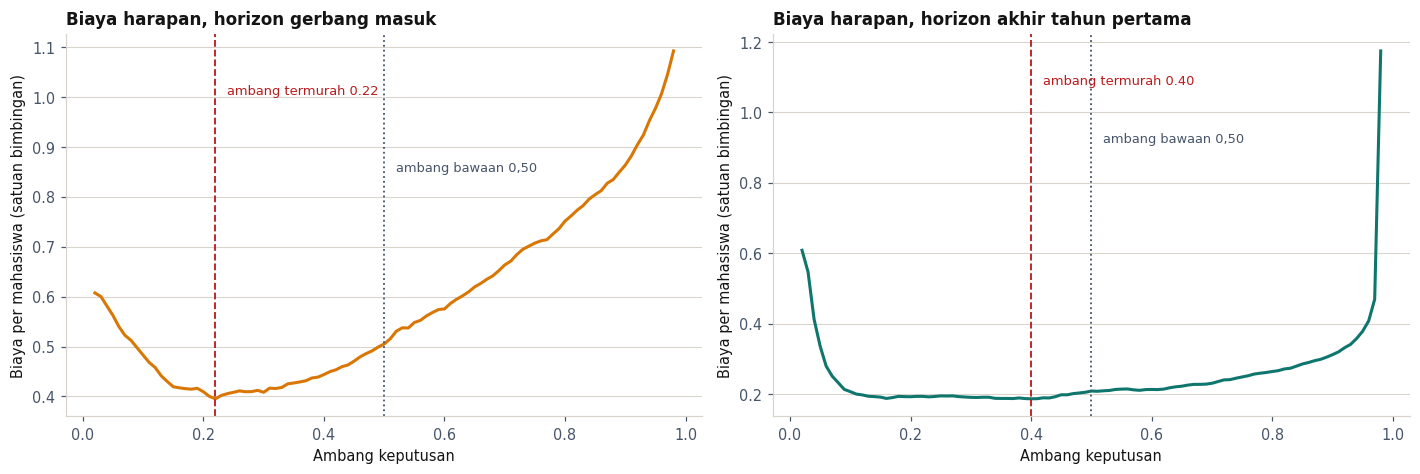

Pengaruh perbandingan biaya terhadap ambang dan hasilnya di data uji
            Horizon  Rasio biaya  Ambang  Akurasi  Presisi  Recall    F1  Bagian dipanggil
      Gerbang masuk  2 banding 1    0.33    0.773    0.684   0.778 0.728             0.445
      Gerbang masuk  3 banding 1    0.22    0.711    0.589   0.866 0.701             0.576
      Gerbang masuk  4 banding 1    0.22    0.711    0.589   0.866 0.701             0.576
      Gerbang masuk  5 banding 1    0.15    0.640    0.523   0.930 0.669             0.696
      Gerbang masuk  8 banding 1    0.15    0.640    0.523   0.930 0.669             0.696
      Gerbang masuk 12 banding 1    0.07    0.540    0.459   0.989 0.627             0.843
Akhir tahun pertama  2 banding 1    0.40    0.906    0.906   0.849 0.876             0.366
Akhir tahun pertama  3 banding 1    0.40    0.906    0.906   0.849 0.876             0.366
Akhir tahun pertama  4 banding 1    0.16    0.893    0.832   0.908 0.869             0.427
Akhir tahun pertama  

In [22]:
BIAYA_LEWAT_DASAR = 3.0   # biaya melewatkan satu calon dropout
BIAYA_SIA_DASAR = 1.0     # biaya membimbing satu mahasiswa yang sebenarnya lulus


def biaya_pada_ambang(label, peluang, lewat, sia):
    """Menghitung biaya rata rata per mahasiswa untuk seluruh calon ambang."""
    calon = np.linspace(0.02, 0.98, 97)
    daftar = []
    for ambang in calon:
        tebakan = (peluang >= ambang).astype(int)
        negatif_palsu = int(((tebakan == 0) & (label == 1)).sum())
        positif_palsu = int(((tebakan == 1) & (label == 0)).sum())
        daftar.append((negatif_palsu * lewat + positif_palsu * sia) / len(label))
    return calon, np.array(daftar)


def ambang_termurah(label, peluang, lewat=BIAYA_LEWAT_DASAR, sia=BIAYA_SIA_DASAR):
    calon, biaya = biaya_pada_ambang(label, peluang, lewat, sia)
    return float(calon[biaya.argmin()]), float(biaya.min())


AMBANG = {}
label_latih = y_latih.to_numpy()

gambar, sumbu = plt.subplots(1, 2, figsize=(13, 4.4))

for indeks, horizon in enumerate(["gerbang", "tahun_pertama"]):
    calon, biaya = biaya_pada_ambang(label_latih, PELUANG_CV[horizon],
                                     BIAYA_LEWAT_DASAR, BIAYA_SIA_DASAR)
    AMBANG[horizon] = float(calon[biaya.argmin()])
    sumbu[indeks].plot(calon, biaya, color=warna_horizon[horizon], linewidth=2)
    sumbu[indeks].axvline(AMBANG[horizon], color=MERAH, linestyle="--", linewidth=1.2)
    sumbu[indeks].axvline(0.5, color=SLATE, linestyle=":", linewidth=1.2)
    puncak = biaya.max()
    sumbu[indeks].text(AMBANG[horizon] + 0.02, puncak * 0.92,
                       f"ambang termurah {AMBANG[horizon]:.2f}", color=MERAH, fontsize=8.5)
    sumbu[indeks].text(0.52, puncak * 0.78, "ambang bawaan 0,50", color=SLATE, fontsize=8.5)
    sumbu[indeks].set_title(f"Biaya harapan, horizon {label_horizon[horizon].lower()}")
    sumbu[indeks].set_xlabel("Ambang keputusan")
    sumbu[indeks].set_ylabel("Biaya per mahasiswa (satuan bimbingan)")
    rapikan(sumbu[indeks])

simpan(gambar, "08_ambang_biaya")

# --- Sensitivitas terhadap perbandingan biaya ----------------------------
baris = []
for horizon in ["gerbang", "tahun_pertama"]:
    for rasio in [2, 3, 4, 5, 8, 12]:
        ambang, _ = ambang_termurah(label_latih, PELUANG_CV[horizon], float(rasio), 1.0)
        tebakan = (PELUANG_UJI[horizon] >= ambang).astype(int)
        baris.append({
            "Horizon": label_horizon[horizon],
            "Rasio biaya": f"{rasio} banding 1",
            "Ambang": ambang,
            "Akurasi": accuracy_score(y_uji, tebakan),
            "Presisi": precision_score(y_uji, tebakan),
            "Recall": recall_score(y_uji, tebakan),
            "F1": f1_score(y_uji, tebakan),
            "Bagian dipanggil": tebakan.mean(),
        })
sensitivitas = pd.DataFrame(baris)
print("Pengaruh perbandingan biaya terhadap ambang dan hasilnya di data uji")
print(sensitivitas.round(3).to_string(index=False))

**Insight 10.** Perhitungan biaya menggeser ambang kedua model ke arah yang berbeda dari
angka bawaan, dan dengan jarak yang berbeda pula. Model tahun pertama berhenti di 0,40,
sedikit di bawah 0,5, sedangkan model gerbang turun jauh ke 0,22. Model yang informasinya
lemah memang harus lebih mudah curiga, karena ia membayar kekurangyakinannya dengan
memanggil lebih banyak orang.

Tabel sensitivitas menunjukkan bahwa keputusan kebijakan ini berkonsekuensi nyata dan
karenanya layak didiskusikan dengan pimpinan, bukan ditetapkan diam diam oleh analis.
Pada model tahun pertama, perbandingan dua sampai tiga banding satu sama sama berhenti
di ambang 0,40 dengan presisi 0,906 dan recall 0,849. Menaikkan perbandingan ke lima
banding satu menjatuhkan ambang ke 0,11: recall naik ke 0,915, tetapi presisi turun ke
0,767 dan bagian mahasiswa yang dipanggil melonjak dari 37 persen menjadi 47 persen.

Perbandingan tiga banding satu dipilih sebagai kebijakan dasar karena ia menahan presisi
di kisaran 0,91 sambil menangkap 85 persen calon dropout, titik yang masih sanggup
dilayani kapasitas bimbingan tanpa membuat staf kehilangan kepercayaan pada daftar yang
diberikan sistem.

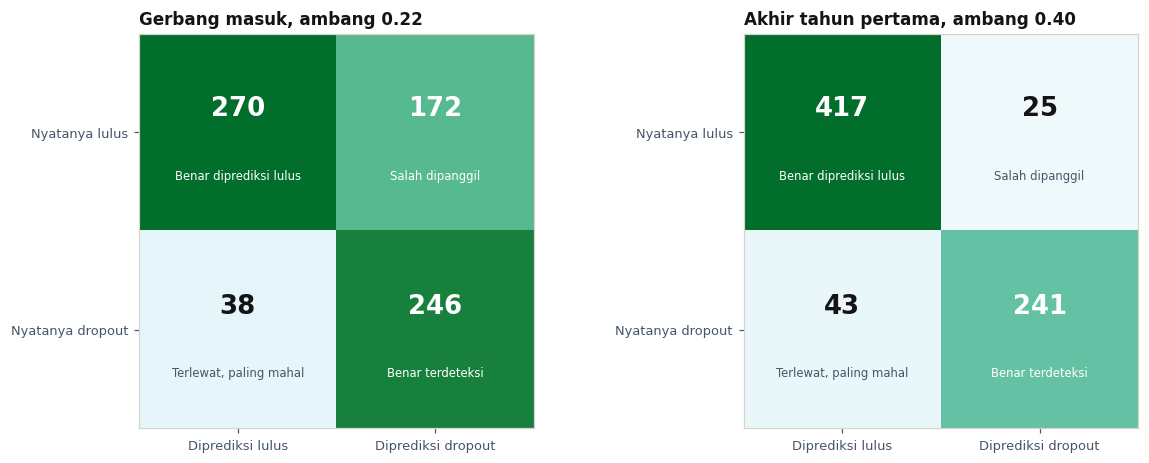

Metrik pada 726 mahasiswa data uji
                     ambang  akurasi  presisi  recall      f1  roc_auc  pr_auc   brier
Gerbang masuk          0.22   0.7107   0.5885  0.8662  0.7009   0.8646  0.8409  0.1403
Akhir tahun pertama    0.40   0.9063   0.9060  0.8486  0.8764   0.9542  0.9521  0.0680


In [23]:
# --- Metrik akhir pada ambang terpilih -----------------------------------
gambar, sumbu = plt.subplots(1, 2, figsize=(11.5, 4.3))
ringkasan_uji = {}

for indeks, horizon in enumerate(["gerbang", "tahun_pertama"]):
    peluang = PELUANG_UJI[horizon]
    tebakan = (peluang >= AMBANG[horizon]).astype(int)
    matriks = confusion_matrix(y_uji, tebakan)
    ringkasan_uji[horizon] = {
        "ambang": AMBANG[horizon],
        "akurasi": accuracy_score(y_uji, tebakan),
        "presisi": precision_score(y_uji, tebakan),
        "recall": recall_score(y_uji, tebakan),
        "f1": f1_score(y_uji, tebakan),
        "roc_auc": roc_auc_score(y_uji, peluang),
        "pr_auc": average_precision_score(y_uji, peluang),
        "brier": brier_score_loss(y_uji, peluang),
    }

    sumbu[indeks].imshow(matriks, cmap="BuGn", vmin=0, vmax=matriks.max() * 1.15)
    keterangan = [["Benar diprediksi lulus", "Salah dipanggil"],
                  ["Terlewat, paling mahal", "Benar terdeteksi"]]
    for i in range(2):
        for j in range(2):
            sumbu[indeks].text(j, i - 0.12, f"{matriks[i, j]}", ha="center", va="center",
                               fontsize=17, fontweight="bold",
                               color="white" if matriks[i, j] > matriks.max() * 0.55 else TINTA)
            sumbu[indeks].text(j, i + 0.22, keterangan[i][j], ha="center", va="center",
                               fontsize=7.6,
                               color="white" if matriks[i, j] > matriks.max() * 0.55 else SLATE)
    sumbu[indeks].set_xticks([0, 1], ["Diprediksi lulus", "Diprediksi dropout"], fontsize=8.5)
    sumbu[indeks].set_yticks([0, 1], ["Nyatanya lulus", "Nyatanya dropout"], fontsize=8.5)
    sumbu[indeks].set_title(f"{label_horizon[horizon]}, ambang {AMBANG[horizon]:.2f}")
    sumbu[indeks].grid(False)

simpan(gambar, "09_matriks_kebingungan")

tabel_akhir = pd.DataFrame(ringkasan_uji).T
tabel_akhir.index = [label_horizon[h] for h in tabel_akhir.index]
print("Metrik pada 726 mahasiswa data uji")
print(tabel_akhir.round(4).to_string())

**Insight 11.** Pada ambang terpilih, model tahun pertama mencapai akurasi 0,906,
presisi 0,906, recall 0,849, dan F1 0,876. Dari 284 mahasiswa yang benar benar dropout
di data uji, 241 tertangkap dan 43 terlewat, sementara hanya 25 mahasiswa dipanggil
padahal akhirnya lulus.

Model gerbang, dengan ambang 0,22, mencapai recall 0,866 pada presisi 0,589. Ia memang
menangkap sedikit lebih banyak calon dropout, yaitu 246 orang, tetapi untuk itu ia harus
memanggil 418 mahasiswa dan 172 di antaranya ternyata lulus. Bagi institusi, angka ini
menerjemahkan pilihan strategis menjadi jumlah yang konkret: bertindak di gerbang berarti
membiayai program untuk sekitar 59 dari 100 sasaran yang tepat, sedangkan menunggu satu
tahun menaikkan ketepatan itu menjadi sekitar 91 dari 100, dengan risiko sebagian
mahasiswa sudah terlanjur pergi.

Kesalahan yang paling mahal, yaitu mahasiswa yang terlewat, ditekan di kedua horizon,
dan itu memang tujuan pemilihan ambang berbasis biaya.

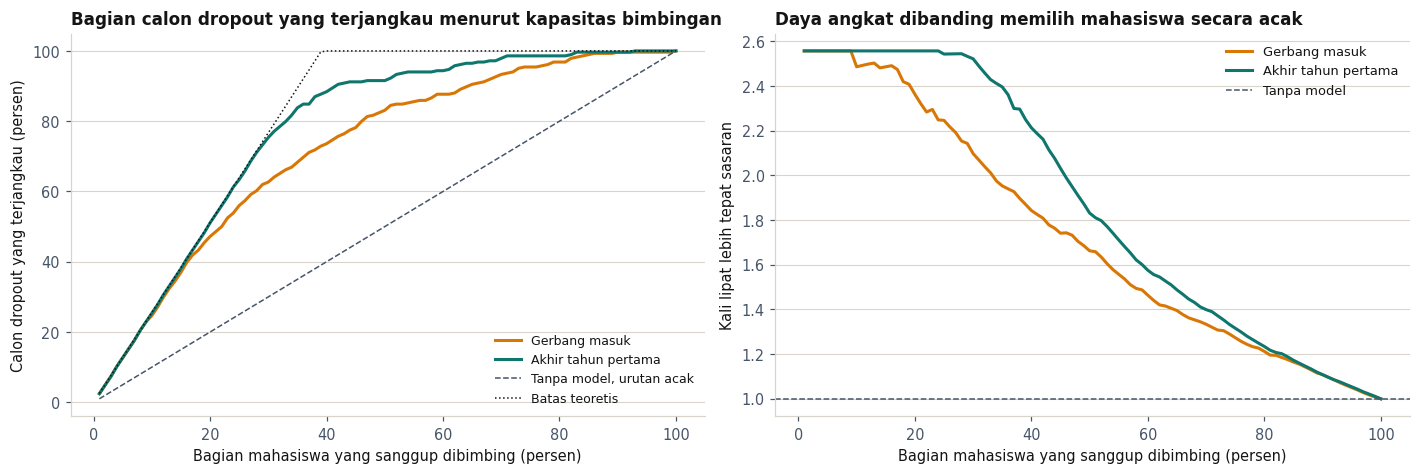

Gerbang masuk          kapasitas  10 persen -> menjangkau  24.6 persen calon dropout, ketepatan daftar  97.2 persen
Gerbang masuk          kapasitas  20 persen -> menjangkau  47.2 persen calon dropout, ketepatan daftar  92.4 persen
Gerbang masuk          kapasitas  30 persen -> menjangkau  62.7 persen calon dropout, ketepatan daftar  82.0 persen
Akhir tahun pertama    kapasitas  10 persen -> menjangkau  25.4 persen calon dropout, ketepatan daftar 100.0 persen
Akhir tahun pertama    kapasitas  20 persen -> menjangkau  51.1 persen calon dropout, ketepatan daftar 100.0 persen
Akhir tahun pertama    kapasitas  30 persen -> menjangkau  75.4 persen calon dropout, ketepatan daftar  98.6 persen


In [24]:
# --- Kurva penangkapan kumulatif -----------------------------------------
# Pertanyaan yang dijawab grafik ini: bila kapasitas bimbingan hanya cukup untuk
# sekian persen mahasiswa, berapa bagian calon dropout yang berhasil dijangkau
# bila mereka didatangi menurut urutan skor model.
gambar, sumbu = plt.subplots(1, 2, figsize=(13, 4.4))

label_uji = y_uji.to_numpy()
total_dropout = label_uji.sum()
proporsi = np.linspace(0.01, 1.0, 100)

for horizon in ["gerbang", "tahun_pertama"]:
    urutan = np.argsort(-PELUANG_UJI[horizon])
    tersusun = label_uji[urutan]
    tertangkap = [tersusun[:max(1, int(p * len(tersusun)))].sum() / total_dropout
                  for p in proporsi]
    sumbu[0].plot(proporsi * 100, np.array(tertangkap) * 100,
                  color=warna_horizon[horizon], linewidth=2, label=label_horizon[horizon])
    daya_angkat = [(tersusun[:max(1, int(p * len(tersusun)))].mean()) / label_uji.mean()
                   for p in proporsi]
    sumbu[1].plot(proporsi * 100, daya_angkat, color=warna_horizon[horizon], linewidth=2,
                  label=label_horizon[horizon])

sumbu[0].plot(proporsi * 100, proporsi * 100, color=SLATE, linestyle="--", linewidth=1,
              label="Tanpa model, urutan acak")
batas_sempurna = np.minimum(proporsi * len(label_uji) / total_dropout, 1) * 100
sumbu[0].plot(proporsi * 100, batas_sempurna, color=TINTA, linestyle=":", linewidth=1,
              label="Batas teoretis")
sumbu[0].set_title("Bagian calon dropout yang terjangkau menurut kapasitas bimbingan")
sumbu[0].set_xlabel("Bagian mahasiswa yang sanggup dibimbing (persen)")
sumbu[0].set_ylabel("Calon dropout yang terjangkau (persen)")
sumbu[0].legend(fontsize=8.2, loc="lower right")

sumbu[1].axhline(1, color=SLATE, linestyle="--", linewidth=1, label="Tanpa model")
sumbu[1].set_title("Daya angkat dibanding memilih mahasiswa secara acak")
sumbu[1].set_xlabel("Bagian mahasiswa yang sanggup dibimbing (persen)")
sumbu[1].set_ylabel("Kali lipat lebih tepat sasaran")
sumbu[1].legend(fontsize=8.5)

for s in sumbu:
    rapikan(s)
simpan(gambar, "10_kurva_penangkapan")

for horizon in ["gerbang", "tahun_pertama"]:
    urutan = np.argsort(-PELUANG_UJI[horizon])
    tersusun = label_uji[urutan]
    for bagian in [0.1, 0.2, 0.3]:
        n = int(bagian * len(tersusun))
        print(f"{label_horizon[horizon]:22s} kapasitas {int(bagian * 100):3d} persen "
              f"-> menjangkau {tersusun[:n].sum() / total_dropout * 100:5.1f} persen calon "
              f"dropout, ketepatan daftar {tersusun[:n].mean() * 100:5.1f} persen")

**Insight 12.** Grafik ini menerjemahkan model menjadi bahasa yang dipakai kepala biro
kemahasiswaan, yaitu kapasitas.

Bila institusi hanya sanggup membimbing 20 persen mahasiswa dalam satu tahun akademik,
mendatangi mereka menurut urutan skor model tahun pertama menjangkau 51,1 persen dari
seluruh calon dropout, dan seluruh isi daftarnya tepat sasaran. Memilih 20 persen
mahasiswa secara acak hanya akan menjangkau 20 persen calon dropout, sehingga model
melipatgandakan hasil kerja tim bimbingan sebesar dua setengah kali. Menambah kapasitas
menjadi 30 persen menaikkan jangkauan ke 75,4 persen. Daya angkat pada kapasitas kecil
menempel pada batas teoretisnya, tanda urutan yang dihasilkan model memang hampir tidak
bisa diperbaiki lagi.

Model gerbang berada di bawahnya, tetapi tetap jelas di atas garis acak. Untuk program
pencegahan berbiaya rendah yang memang ditujukan ke kelompok, misalnya kelas pengenalan
tambahan atau penawaran cicilan uang kuliah, daya angkat sebesar itu sudah cukup untuk
membenarkan penggunaannya.

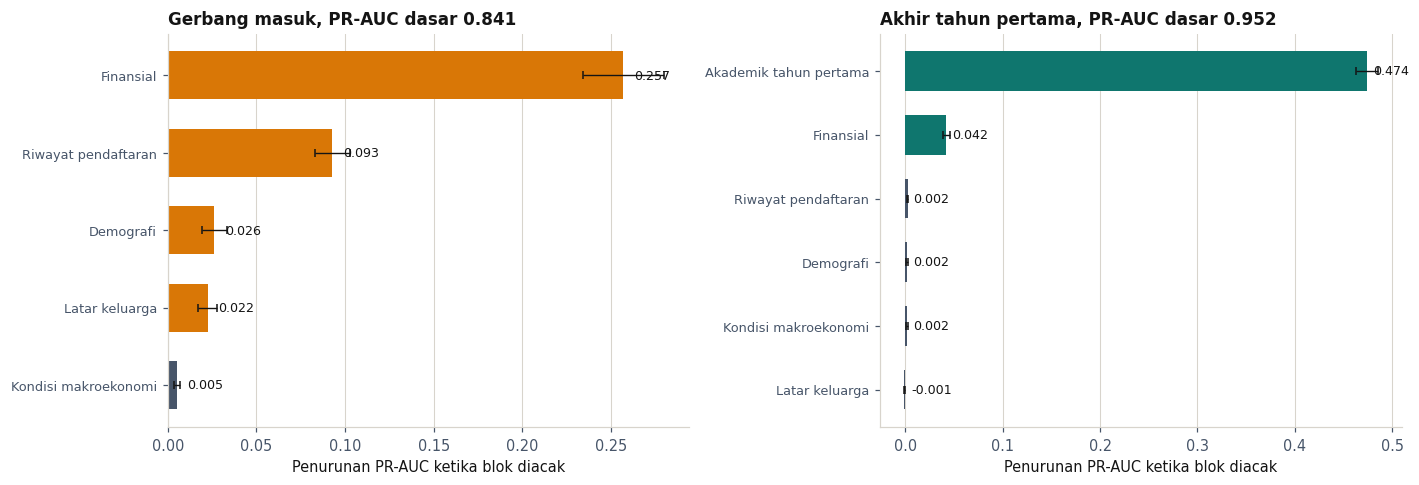

Penurunan PR-AUC ketika satu blok informasi diacak
                        Gerbang masuk  Akhir tahun pertama
Akademik tahun pertama         0.0000               0.4739
Finansial                      0.2571               0.0421
Riwayat pendaftaran            0.0928               0.0025
Demografi                      0.0262               0.0017
Kondisi makroekonomi           0.0052               0.0016
Latar keluarga                 0.0224              -0.0012


In [25]:
# --- Kepentingan per blok informasi --------------------------------------
# Kolom mentah satu blok diacak bersama sama, lalu penurunan PR-AUC diukur.
# Cara ini lebih jujur daripada mengacak kolom satu per satu, karena kolom yang
# saling berkorelasi, misalnya jumlah mata kuliah lulus dan daya selesai, dapat
# saling menutupi ketika diacak sendiri sendiri sehingga keduanya tampak tidak penting.
def kepentingan_blok(model, X_asal, y_asal, kolom_tersedia, pengulangan=5, benih=ACAK):
    acak = np.random.default_rng(benih)
    dasar = average_precision_score(y_asal, model.predict_proba(X_asal)[:, 1])
    hasil = {}
    for nama_blok, kolom in fa.BLOK_FITUR.items():
        kolom_dipakai = [k for k in kolom if k in kolom_tersedia]
        if not kolom_dipakai:
            continue
        penurunan = []
        for _ in range(pengulangan):
            salinan = X_asal.copy()
            urutan_acak = acak.permutation(len(salinan))
            for k in kolom_dipakai:
                salinan[k] = salinan[k].to_numpy()[urutan_acak]
            penurunan.append(dasar - average_precision_score(
                y_asal, model.predict_proba(salinan)[:, 1]))
        hasil[nama_blok] = (float(np.mean(penurunan)), float(np.std(penurunan)))
    return dasar, hasil


gambar, sumbu = plt.subplots(1, 2, figsize=(13, 4.5))
KEPENTINGAN = {}

for indeks, horizon in enumerate(["gerbang", "tahun_pertama"]):
    mentah, _ = fa.daftar_fitur(horizon)
    dasar, hasil = kepentingan_blok(MODEL_FINAL[horizon], X_uji, y_uji, mentah)
    KEPENTINGAN[horizon] = hasil
    tersusun = sorted(hasil.items(), key=lambda x: x[1][0])
    nama_blok = [t[0] for t in tersusun]
    nilai = [t[1][0] for t in tersusun]
    galat = [t[1][1] for t in tersusun]
    warna_blok = [warna_horizon[horizon] if n > 0.01 else SLATE for n in nilai]
    sumbu[indeks].barh(nama_blok, nilai, xerr=galat, color=warna_blok, height=0.62,
                       error_kw={"ecolor": TINTA, "elinewidth": 0.9, "capsize": 2.5})
    for posisi, n in enumerate(nilai):
        sumbu[indeks].text(max(n, 0) + 0.006, posisi, f"{n:.3f}", va="center", fontsize=8.3)
    sumbu[indeks].set_title(f"{label_horizon[horizon]}, PR-AUC dasar {dasar:.3f}")
    sumbu[indeks].set_xlabel("Penurunan PR-AUC ketika blok diacak")
    sumbu[indeks].tick_params(axis="y", labelsize=8.4)
    sumbu[indeks].yaxis.grid(False)
    for sisi in ("top", "right"):
        sumbu[indeks].spines[sisi].set_visible(False)

simpan(gambar, "11_kepentingan_blok")

tabel_kepentingan = pd.DataFrame({
    label_horizon[h]: {nama: round(nilai[0], 4) for nama, nilai in KEPENTINGAN[h].items()}
    for h in ["gerbang", "tahun_pertama"]
}).fillna(0)
print("Penurunan PR-AUC ketika satu blok informasi diacak")
print(tabel_kepentingan.sort_values("Akhir tahun pertama", ascending=False).to_string())

**Insight 13.** Menjawab langsung permasalahan bisnis pertama, inilah urutan blok
informasi menurut sumbangan nyatanya terhadap kemampuan model.

Pada horizon tahun pertama, blok akademik mendominasi sendirian. Mengacak dua belas kolom
catatan semester menjatuhkan PR-AUC sebesar 0,474, sementara blok finansial hanya 0,042
dan blok demografi, latar keluarga, serta makroekonomi berada di sekitar nol. Ini
menegaskan bahwa begitu mahasiswa mulai kuliah, perilaku akademiknyalah yang berbicara,
bukan asal usulnya.

Pada horizon gerbang, ketika blok akademik memang tidak tersedia, blok finansial menjadi
penyumbang terbesar dengan penurunan 0,257, disusul riwayat pendaftaran 0,093 dan
demografi 0,026. Blok latar keluarga 0,022 dan makroekonomi 0,005 kembali nyaris tidak
menyumbang apa apa, sejalan dengan hasil uji statistik pada bagian EDA.

Temuan ini punya nilai praktis di luar pemodelan: institusi tidak perlu mengumpulkan
data tambahan tentang keluarga mahasiswa untuk keperluan peringatan dini. Yang perlu
dijaga justru mutu pencatatan keuangan dan kecepatan masuknya nilai semester ke sistem.

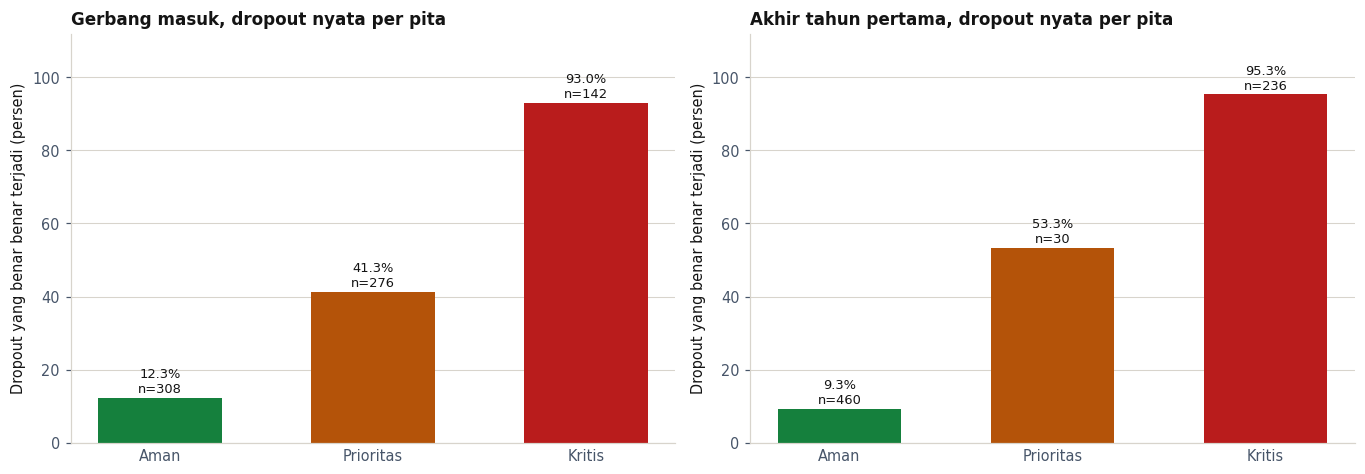


Gerbang masuk
           jumlah  rasio
pita                    
Aman          308   12.3
Prioritas     276   41.3
Kritis        142   93.0

Akhir tahun pertama
           jumlah  rasio
pita                    
Aman          460    9.3
Prioritas      30   53.3
Kritis        236   95.3


In [26]:
# --- Pita risiko ----------------------------------------------------------
BATAS_KRITIS = 0.65
WARNA_PITA = {"Aman": HIJAU, "Prioritas": EMAS, "Kritis": MERAH}

gambar, sumbu = plt.subplots(1, 2, figsize=(12.5, 4.4))
tabel_pita = {}

for indeks, horizon in enumerate(["gerbang", "tahun_pertama"]):
    pita = fa.pita_risiko(PELUANG_UJI[horizon], AMBANG[horizon], BATAS_KRITIS)
    ringkas = (pd.DataFrame({"pita": pita.to_numpy(), "nyata": y_uji.to_numpy()})
                 .groupby("pita")
                 .agg(jumlah=("nyata", "size"), rasio=("nyata", "mean"))
                 .reindex(fa.PITA_RISIKO).fillna(0))
    tabel_pita[horizon] = ringkas
    batang = sumbu[indeks].bar(ringkas.index, ringkas.rasio * 100,
                               color=[WARNA_PITA[p] for p in ringkas.index], width=0.58)
    for b, (jumlah, rasio) in zip(batang, zip(ringkas.jumlah, ringkas.rasio)):
        sumbu[indeks].text(b.get_x() + b.get_width() / 2, rasio * 100 + 1.5,
                           f"{rasio * 100:.1f}%\nn={int(jumlah)}", ha="center", fontsize=8.5)
    sumbu[indeks].set_title(f"{label_horizon[horizon]}, dropout nyata per pita")
    sumbu[indeks].set_ylabel("Dropout yang benar benar terjadi (persen)")
    sumbu[indeks].set_ylim(0, 112)
    rapikan(sumbu[indeks], sembunyikan_x=True)

simpan(gambar, "12_pita_risiko")

for horizon in ["gerbang", "tahun_pertama"]:
    print(f"\n{label_horizon[horizon]}")
    print(tabel_pita[horizon].assign(rasio=lambda t: (t.rasio * 100).round(1)).to_string())

**Insight 14.** Tiga pita tindak lanjut disusun dari ambang keputusan, bukan dari angka
bulat yang dipilih sembarangan. Pita Aman berisi mahasiswa di bawah ambang, pita
Prioritas berisi mereka yang dipanggil model, dan pita Kritis berisi bagian teratas
dengan skor 0,65 ke atas.

Pada model tahun pertama pemisahannya tajam. Pita Aman berisi 460 mahasiswa dan hanya
9,3 persen di antaranya benar benar dropout, sedangkan pita Kritis berisi 236 mahasiswa
dengan 95,3 persen benar benar dropout. Pita Prioritas di tengah hanya berisi 30
mahasiswa dengan 53,3 persen dropout, dan justru kelompok kecil inilah yang paling
membutuhkan penilaian manusia, karena di situ model sendiri hampir tidak punya pendapat.

Pada model gerbang pemisahannya lebih landai, dan itu memang jujur adanya. Pita Kritis
mencapai 93,0 persen, tetapi pita Aman masih menyisakan 12,3 persen dropout. Karena itu
kelompok Aman di gerbang tidak boleh dianggap bebas risiko, melainkan sekadar bukan
prioritas pertama.

### 7.3. Menerapkan model pada mahasiswa yang masih aktif

Bagian ini adalah alasan seluruh proyek dikerjakan. Model diterapkan pada 794 mahasiswa
berstatus aktif, yaitu kelompok yang hasil akhirnya belum ditentukan dan karena itu masih
mungkin diubah.

Kedua horizon dipakai sekaligus. Skor gerbang menunjukkan risiko bawaan yang sudah
melekat sejak mereka mendaftar, sedangkan skor tahun pertama menunjukkan keadaan
terkini. Selisih keduanya sendiri merupakan informasi: mahasiswa yang skor gerbangnya
rendah tetapi skor tahun pertamanya tinggi adalah kasus penurunan yang terjadi setelah
kuliah dimulai, dan biasanya paling layak ditolong lebih dulu karena penyebabnya masih
berada di dalam jangkauan kampus.

In [27]:
skor_aktif = data_aktif.drop(columns=["Status"]).copy()
hasil_aktif = data_aktif[["Course", "Age_at_enrollment", "Gender", "Debtor",
                          "Tuition_fees_up_to_date", "Scholarship_holder"]].copy()
hasil_aktif.insert(0, "id_mahasiswa", [f"MHS{n:04d}" for n in range(1, len(hasil_aktif) + 1)])
hasil_aktif["program_studi"] = data_aktif.Course.map(kk.PROGRAM_STUDI)

for horizon in ["gerbang", "tahun_pertama"]:
    peluang = MODEL_FINAL[horizon].predict_proba(skor_aktif)[:, 1]
    hasil_aktif[f"skor_{horizon}"] = peluang.round(4)
    hasil_aktif[f"pita_{horizon}"] = fa.pita_risiko(peluang, AMBANG[horizon],
                                                    BATAS_KRITIS).to_numpy()

hasil_aktif["kenaikan_risiko"] = (hasil_aktif.skor_tahun_pertama
                                  - hasil_aktif.skor_gerbang).round(4)
hasil_aktif = hasil_aktif.sort_values("skor_tahun_pertama", ascending=False)
hasil_aktif.to_csv("dataset/mahasiswa_aktif_terskor.csv", index=False, sep=";")

sebaran_pita = hasil_aktif.pita_tahun_pertama.value_counts().reindex(fa.PITA_RISIKO)
print("Sebaran pita risiko 794 mahasiswa aktif menurut model tahun pertama")
for pita, jumlah in sebaran_pita.items():
    print(f"  {pita:10s} {int(jumlah):4d} mahasiswa  ({jumlah / len(hasil_aktif) * 100:.1f} persen)")
print()
naik_tajam = hasil_aktif[(hasil_aktif.skor_gerbang < AMBANG['gerbang'])
                         & (hasil_aktif.skor_tahun_pertama >= AMBANG['tahun_pertama'])]
print(f"Mahasiswa yang aman di gerbang tetapi berisiko sekarang: {len(naik_tajam)} orang.")
print("Kelompok inilah yang penurunannya terjadi selama kuliah berlangsung.")
print()
print("Sepuluh mahasiswa aktif dengan risiko tertinggi")
print(hasil_aktif.head(10)[["id_mahasiswa", "program_studi", "skor_gerbang",
                            "skor_tahun_pertama", "kenaikan_risiko",
                            "pita_tahun_pertama"]].to_string(index=False))

Sebaran pita risiko 794 mahasiswa aktif menurut model tahun pertama
  Aman        381 mahasiswa  (48.0 persen)
  Prioritas    73 mahasiswa  (9.2 persen)
  Kritis      340 mahasiswa  (42.8 persen)

Mahasiswa yang aman di gerbang tetapi berisiko sekarang: 84 orang.
Kelompok inilah yang penurunannya terjadi selama kuliah berlangsung.

Sepuluh mahasiswa aktif dengan risiko tertinggi
id_mahasiswa                      program_studi  skor_gerbang  skor_tahun_pertama  kenaikan_risiko pita_tahun_pertama
     MHS0787                   Pekerjaan Sosial        0.1213              0.9801           0.8588             Kritis
     MHS0488 Manajemen Periklanan dan Pemasaran        0.4666              0.9801           0.5135             Kritis
     MHS0044          Jurnalisme dan Komunikasi        0.2149              0.9801           0.7652             Kritis
     MHS0616                          Manajemen        0.3699              0.9801           0.6102             Kritis
     MHS0168                

**Insight 15.** Dari 794 mahasiswa aktif, model tahun pertama menempatkan 381 orang di
pita Aman, 73 orang di pita Prioritas, dan 340 orang di pita Kritis. Rata rata skor
kelompok aktif adalah 0,508, tepat di antara rata rata kelompok yang akhirnya lulus
sebesar 0,107 dan yang akhirnya dropout sebesar 0,825. Kelompok aktif memang berada di
tengah, dan itulah alasan mereka masih bisa diarahkan ke salah satu ujung.

Jumlah 413 mahasiswa di pita Prioritas dan Kritis jelas melampaui kapasitas bimbingan
mana pun dalam satu semester. Di sinilah urutan menjadi lebih penting daripada penanda:
daftar dikerjakan dari puncak sesuai kapasitas nyata, bukan dituntaskan sekaligus.

Delapan puluh empat mahasiswa tergolong aman di gerbang tetapi berisiko sekarang. Mereka
masuk dengan bekal memadai, sehingga penyebab kemundurannya kemungkinan besar terjadi di
dalam kampus, dan hal semacam itu justru berada dalam kendali institusi. Merekalah yang
paling layak didahulukan.

Berkas `dataset/mahasiswa_aktif_terskor.csv` inilah yang menjadi sumber kartu daftar
prioritas pada dashboard Metabase.

## 8. Penyimpanan Artefak

Tiga jenis artefak disimpan supaya dashboard dan prototipe tidak perlu melatih ulang
model, dan supaya hasil notebook ini dapat dipakai kembali tanpa perubahan.

1. Dua berkas model terkalibrasi dalam format joblib.
2. Satu berkas metadata JSON berisi ambang, metrik, daftar fitur, nilai bawaan formulir,
   dan hasil analisis kepentingan blok.
3. Satu tabel siap pakai berisi seluruh mahasiswa beserta skor risikonya untuk dashboard.

In [28]:
joblib.dump(MODEL_FINAL["gerbang"], "model/model_gerbang.joblib", compress=3)
joblib.dump(MODEL_FINAL["tahun_pertama"], "model/model_tahun_pertama.joblib", compress=3)

for berkas in ["model_gerbang.joblib", "model_tahun_pertama.joblib"]:
    print(f"model/{berkas:28s} {os.path.getsize('model/' + berkas) / 1024:8.1f} KB")

model/model_gerbang.joblib              6.0 KB
model/model_tahun_pertama.joblib    11085.6 KB


In [29]:
# --- Nilai bawaan dan pilihan untuk formulir prototipe -------------------
kolom_semua = fa.KOLOM_MENTAH
nilai_bawaan = {}
for kolom in kolom_semua:
    if kolom in fa.KOLOM_KATEGORI or kolom in fa.KOLOM_BINER:
        nilai_bawaan[kolom] = int(df[kolom].mode().iloc[0])
    else:
        nilai_bawaan[kolom] = float(round(df[kolom].median(), 3))

rentang = {kolom: {"min": float(df[kolom].min()), "max": float(df[kolom].max())}
           for kolom in kolom_semua}

# Kode wakil untuk tiap kelompok pendidikan dan pekerjaan orang tua: kode yang
# paling sering muncul di dalam kelompoknya, supaya formulir cukup menanyakan
# jenjang atau kelompok pekerjaan alih alih 34 kode mentah.
def kode_wakil(kolom, pemeta):
    kelompok = df[kolom].map(pemeta)
    wakil = {}
    for nama_kelompok in kelompok.unique():
        anggota = df.loc[kelompok == nama_kelompok, kolom]
        wakil[nama_kelompok] = int(anggota.mode().iloc[0])
    return wakil

metadata = {
    "identitas": {
        "nama": "Muhammad Shobir Abdussyakur",
        "id_dicoding": "souba676",
        "proyek": "Sistem peringatan dini dua horizon untuk retensi mahasiswa",
        "versi": "1.0.0",
    },
    "data": {
        "sumber": "https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance",
        "baris_total": int(len(df)),
        "baris_berlabel": int(len(X)),
        "baris_latih": int(len(X_latih)),
        "baris_uji": int(len(X_uji)),
        "baris_aktif": int(len(data_aktif)),
        "prevalensi_dropout_berlabel": float(round(y.mean(), 4)),
    },
    "biaya": {
        "melewatkan_dropout": BIAYA_LEWAT_DASAR,
        "membimbing_yang_lulus": BIAYA_SIA_DASAR,
        "catatan": "Perbandingan biaya adalah keputusan kebijakan, bukan hasil estimasi data.",
    },
    "batas_kritis": BATAS_KRITIS,
    "pita_risiko": fa.PITA_RISIKO,
    "horizon": {},
    "nilai_bawaan": nilai_bawaan,
    "rentang": rentang,
    "pilihan": {
        "program_studi": {str(k): kk.PROGRAM_STUDI[k] for k in sorted(df.Course.unique())},
        "jalur_masuk": {str(k): kk.JALUR_MASUK[k] for k in sorted(df.Application_mode.unique())},
        "status_nikah": {str(k): kk.STATUS_NIKAH[k]
                         for k in sorted(df.Marital_status.unique())},
        "kualifikasi_sebelumnya": {str(k): kk.KUALIFIKASI_SEBELUMNYA[k]
                                   for k in sorted(df.Previous_qualification.unique())},
        "jenjang_ibu": kode_wakil("Mothers_qualification", kk.jenjang_orang_tua),
        "jenjang_ayah": kode_wakil("Fathers_qualification", kk.jenjang_orang_tua),
        "pekerjaan_ibu": kode_wakil("Mothers_occupation", kk.kelompok_pekerjaan),
        "pekerjaan_ayah": kode_wakil("Fathers_occupation", kk.kelompok_pekerjaan),
    },
}

for horizon in ["gerbang", "tahun_pertama"]:
    mentah, turunan = fa.daftar_fitur(horizon)
    jenis = TERBAIK[horizon]
    seluruh_parameter = PIPA_TERSETEL[horizon].get_params()
    parameter = {kunci: str(seluruh_parameter[kunci]) for kunci in RUANG_PARAMETER[jenis]}
    metadata["horizon"][horizon] = {
        "nama_model": NAMA_KANDIDAT[jenis],
        "kalibrasi": ("isotonik" if METODE_KALIBRASI[horizon] == "isotonic"
                      else "Platt scaling") + ", lima lipatan, tanpa ensemble",
        "kolom_mentah": mentah,
        "fitur_turunan": turunan,
        "ambang_keputusan": round(AMBANG[horizon], 4),
        "metrik_uji": {k: round(float(v), 4) for k, v in ringkasan_uji[horizon].items()},
        "kepentingan_blok": {k: round(v[0], 4) for k, v in KEPENTINGAN[horizon].items()},
        "parameter_terpilih": parameter,
    }

with open("model/metadata_model.json", "w", encoding="utf-8") as berkas:
    json.dump(metadata, berkas, indent=2, ensure_ascii=False)

print("model/metadata_model.json tersimpan.")
print(json.dumps({h: {"model": v["nama_model"], "ambang": v["ambang_keputusan"],
                      "metrik": v["metrik_uji"]}
                  for h, v in metadata["horizon"].items()}, indent=2, ensure_ascii=False))

model/metadata_model.json tersimpan.
{
  "gerbang": {
    "model": "Regresi Logistik",
    "ambang": 0.22,
    "metrik": {
      "ambang": 0.22,
      "akurasi": 0.7107,
      "presisi": 0.5885,
      "recall": 0.8662,
      "f1": 0.7009,
      "roc_auc": 0.8646,
      "pr_auc": 0.8409,
      "brier": 0.1403
    }
  },
  "tahun_pertama": {
    "model": "Extra Trees",
    "ambang": 0.4,
    "metrik": {
      "ambang": 0.4,
      "akurasi": 0.9063,
      "presisi": 0.906,
      "recall": 0.8486,
      "f1": 0.8764,
      "roc_auc": 0.9542,
      "pr_auc": 0.9521,
      "brier": 0.068
    }
  }
}


In [30]:
# --- Uji muat ulang: memastikan berkas model benar benar dapat dipakai ---
ulang = joblib.load("model/model_tahun_pertama.joblib")
contoh_dua = X_uji.head(2)
selisih = np.abs(ulang.predict_proba(contoh_dua)[:, 1]
                 - MODEL_FINAL["tahun_pertama"].predict_proba(contoh_dua)[:, 1]).max()
print(f"Selisih prediksi model asli dan model yang dimuat ulang: {selisih:.10f}")
print("Model siap dipakai oleh app.py.")

Selisih prediksi model asli dan model yang dimuat ulang: 0.0000000000
Model siap dipakai oleh app.py.


In [31]:
# --- Tabel untuk dashboard Metabase --------------------------------------
# Mahasiswa berlabel diberi skor luar lipatan pada bagian data latih dan skor
# model final pada bagian data uji. Dengan begitu tidak ada satu pun mahasiswa
# yang dinilai oleh model yang pernah melihat dirinya sendiri, sehingga angka
# pada dashboard tidak dilebih lebihkan oleh hafalan model.
dashboard = df.copy()
dashboard.insert(0, "id_mahasiswa", [f"MHS{n:04d}" for n in range(1, len(dashboard) + 1)])

for horizon in ["gerbang", "tahun_pertama"]:
    skor = pd.Series(np.nan, index=dashboard.index, dtype=float)
    skor.loc[X_latih.index] = PELUANG_CV[horizon]
    skor.loc[X_uji.index] = PELUANG_UJI[horizon]
    baris_aktif = data_aktif.index
    skor.loc[baris_aktif] = MODEL_FINAL[horizon].predict_proba(
        data_aktif.drop(columns=["Status"]))[:, 1]
    dashboard[f"skor_{horizon}"] = skor.round(4)
    dashboard[f"pita_{horizon}"] = fa.pita_risiko(skor, AMBANG[horizon],
                                                  BATAS_KRITIS).to_numpy()

dashboard["asal_skor"] = np.where(dashboard.index.isin(X_latih.index), "validasi silang",
                                  np.where(dashboard.index.isin(X_uji.index), "data uji",
                                           "mahasiswa aktif"))
dashboard.to_csv("dataset/mahasiswa_berskor.csv", index=False, sep=";")

print(f"dataset/mahasiswa_berskor.csv tersimpan: {dashboard.shape[0]:,} baris, "
      f"{dashboard.shape[1]} kolom.")
print()
print("Uji kewarasan, rata rata skor tahun pertama menurut status sebenarnya")
print(dashboard.groupby("Status").skor_tahun_pertama.agg(["count", "mean"]).round(3).to_string())

dataset/mahasiswa_berskor.csv tersimpan: 4,424 baris, 43 kolom.

Uji kewarasan, rata rata skor tahun pertama menurut status sebenarnya


          count   mean
Status                
Dropout    1421  0.825
Enrolled    794  0.508
Graduate   2209  0.107


## 9. Conclusion

Proyek ini berangkat dari satu pertanyaan yang tidak bisa dijawab laporan akhir tahun:
siapa yang akan berhenti, dan apakah masih ada waktu untuk menahannya. Berikut jawaban
atas kelima permasalahan bisnis yang dirumuskan di awal.

**1. Faktor apa yang paling menentukan mahasiswa berhenti studi.**

Jawabannya berubah tergantung kapan pertanyaan diajukan.

Sebelum kuliah dimulai, kondisi keuangan adalah penentu terkuat. Skor dukungan finansial
memisahkan populasi dari 88,8 persen dropout pada kelompok terendah sampai 9,3 persen
pada kelompok tertinggi. Usia saat mendaftar dan jalur masuk menyusul di belakangnya,
dengan jalur usia di atas 23 tahun berakhir dropout pada 55,4 persen kasus dibanding
20,2 persen pada seleksi umum gelombang pertama.

Setelah satu tahun berjalan, catatan akademik mengambil alih sepenuhnya. Daya selesai
tahun pertama memisahkan dari 80,8 persen dropout pada mahasiswa yang tidak meluluskan
satu pun mata kuliah, menjadi 5,2 persen pada mahasiswa yang meluluskan seluruhnya.
Analisis kepentingan blok menegaskannya: mengacak blok akademik menjatuhkan kemampuan
model jauh lebih besar daripada mengacak blok mana pun.

Sama pentingnya, dua dugaan umum tidak terbukti. Latar belakang pendidikan orang tua
hampir tidak membedakan, dan kondisi makroekonomi tidak memberi informasi yang berguna
untuk membedakan mahasiswa satu sama lain.

**2. Apakah mahasiswa berisiko dapat dikenali sebelum berhenti.**

Bisa, dengan tingkat kepastian yang berbeda pada dua titik waktu. Model gerbang, sebuah
Regresi Logistik terkalibrasi, mencapai ROC-AUC 0,865 hanya dengan berkas pendaftaran.
Model akhir tahun pertama, sebuah Extra Trees terkalibrasi, mencapai ROC-AUC 0,954
dengan akurasi 0,906, presisi 0,906, dan recall 0,849 pada 726 mahasiswa data uji yang
belum pernah dilihat.

Selisih itu adalah harga dari kecepatan. Bertindak di gerbang berarti menerima daftar
yang sekitar 59 persen isinya tepat sasaran. Menunggu satu tahun menaikkan ketepatan
menjadi sekitar 91 persen, dengan risiko sebagian mahasiswa sudah pergi lebih dulu.
Karena itu keduanya dipakai bersama, bukan dipilih salah satu.

**3. Bagaimana kapasitas bimbingan yang terbatas dialokasikan.**

Model mengubah pertanyaan siapa yang berisiko menjadi pertanyaan siapa yang didahulukan.
Bila kapasitas hanya cukup untuk 20 persen mahasiswa, mendatangi mereka menurut urutan
skor menjangkau 51,1 persen dari seluruh calon dropout, dua setengah kali lebih banyak
dibanding memilih secara acak, dan seluruh isi daftarnya tepat sasaran. Ambang keputusan
pun tidak diambil dari angka bawaan 0,5, melainkan dihitung dari perbandingan biaya tiga
banding satu, dan sensitivitasnya terhadap perbandingan lain sudah disajikan agar
pimpinan dapat menggesernya secara sadar.

**4. Alat pantau mandiri untuk bagian akademik.**

Dashboard Metabase bernama Pusat Pemantauan Retensi Mahasiswa menjawab kebutuhan ini
lewat delapan belas visualisasi yang tersusun dalam empat seksi, dari potret retensi saat
ini, sinyal gerbang masuk, sinyal tahun pertama, sampai hasil model. Empat penyaring
interaktif, yaitu program studi, waktu kuliah, status pembayaran, dan pita risiko,
memungkinkan bagian akademik menjawab pertanyaan barunya sendiri tanpa meminta laporan
baru ke bagian lain.

**5. Mahasiswa yang statusnya masih aktif.**

794 mahasiswa aktif sengaja dikeluarkan dari pelatihan karena hasil akhirnya belum ada,
lalu diskor memakai kedua model. Hasilnya tersimpan pada
`dataset/mahasiswa_aktif_terskor.csv`, lengkap dengan pita risiko dan selisih skor antar
horizon. Model menempatkan 340 di antaranya pada pita Kritis dan 73 pada pita Prioritas.
Delapan puluh empat mahasiswa tergolong aman di gerbang tetapi berisiko sekarang, dan
kelompok inilah yang mendapat perhatian pertama karena penyebab kemundurannya berada di
dalam jangkauan kampus.

### 9.1. Rekomendasi Action Items

Lima tindakan berikut disusun menurut urutan dampak dibanding usaha, dan seluruhnya
bersandar pada temuan di atas.

**1. Jadikan status pembayaran sebagai pemicu peringatan otomatis, bukan sekadar catatan
keuangan.**
Mahasiswa dengan pembayaran tertunggak berakhir dropout pada 86,6 persen kasus. Bagian
keuangan sudah memiliki data ini sejak hari pertama, tetapi belum pernah mengalirkannya
ke bagian akademik. Buat aturan sederhana: begitu status berubah menjadi tertunggak,
sistem mengirim pemberitahuan ke dosen wali dalam waktu tujuh hari, dan mahasiswa
ditawari skema cicilan atau keringanan sebelum tunggakan menumpuk. Tindakan ini tidak
memerlukan model sama sekali dan bisa dijalankan bulan depan.

**2. Pantau daya selesai di tengah semester, jangan tunggu nilai akhir.**
Daya selesai tahun pertama adalah sinyal terkuat, tetapi ia baru lengkap ketika satu
tahun sudah lewat. Yang tidak perlu menunggu adalah jumlah mata kuliah tanpa evaluasi,
yang sudah dapat dihitung di pertengahan semester dan menaikkan tingkat dropout dari
31,0 persen menjadi 45,9 persen ketika mencapai dua mata kuliah atau lebih. Jadikan
angka ini laporan mingguan dosen wali.

**3. Jalankan program pengenalan terarah untuk kelompok berisiko bawaan.**
Model gerbang tidak cukup tepat untuk menuduh perorangan, tetapi cukup baik untuk
menyaring kelompok. Mahasiswa jalur usia di atas 23 tahun, mahasiswa yang mendaftar pada
usia di atas 24 tahun, dan mahasiswa tanpa dukungan finansial layak mendapat program
pengenalan tambahan, kelas keterampilan belajar, dan penempatan mentor sejak semester
pertama. Program semacam ini berbiaya rendah per orang sehingga presisi 58 persen masih
dapat diterima.

**4. Alokasikan kapasitas bimbingan menurut daftar prioritas, bukan menurut permintaan.**
Selama ini bimbingan diberikan kepada mahasiswa yang datang sendiri, dan mahasiswa yang
paling berisiko justru yang paling jarang datang. Pakai daftar prioritas dari prototipe:
tetapkan kapasitas nyata konselor per bulan, ambil sejumlah itu dari puncak daftar, dan
catat hasil tiap panggilan. Pencatatan hasil ini sekaligus menjadi bahan pelatihan ulang
model di tahun berikutnya.

**5. Tangani program studi berisiko tinggi sebagai persoalan program, bukan persoalan
mahasiswa.**
Manajemen Kuda pada 55,3 persen dan Teknik Informatika pada 54,1 persen memiliki tingkat
dropout lebih dari tiga kali lipat Keperawatan pada 15,4 persen. Perbedaan sebesar itu
tidak dapat dijelaskan oleh mutu mahasiswa semata. Lakukan telaah kurikulum pada mata
kuliah tahun pertama di kedua program tersebut, khususnya mata kuliah dengan tingkat
kelulusan terendah, dan pertimbangkan penyesuaian beban studi semester pertama.

**Catatan penerapan.** Model ini memberi peringkat risiko, bukan vonis. Skor tinggi
berarti mahasiswa pantas ditanyai kabarnya lebih dulu, bukan bahwa ia pasti berhenti.
Beberapa variabel berkaitan kuat dengan dropout tetapi tidak boleh dijadikan dasar
perlakuan yang merugikan, khususnya jenis kelamin dan usia. Pemakaian yang benar adalah
menambah dukungan bagi kelompok berisiko, bukan mengurangi kesempatan mereka. Model juga
perlu dilatih ulang setiap tahun akademik, karena kurikulum, kebijakan biaya, dan profil
pendaftar berubah dari waktu ke waktu.